# CVaR Lagrangian vs PB RBF

## Imports

In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

from performance_boosting import PBClosedLoop
from ren import ContractiveREN
from robot import RobotPlant, StabilizedRobot, PDController
from dataset import generate_random_batch
from losses_and_wrappers import PBLoss, ERMWrapper, LagrangianCVaRLossWrapper
from training_function import train_agent
from plot_functions import plot_pb_trajectories

## Helper Functions

In [5]:
from typing import Optional

def set_seed(seed: int):
    torch.manual_seed(seed)
    np.random.seed(seed)


@dataclass
class ExperimentConfig:
    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    seed: int = 4

    n_agents: int = 1
    state_dim: int = 4
    input_dim: int = 2
    dt: float = 0.05
    b_nom: float = 1.0
    m_nom: float = 1.0
    b2_nom: float = 0.2
    b_sim: float = 1.0
    m_sim: float = 1.0
    b2_sim: float = 0.2

    initialization_std: float = 0.01
    dim_internal: int = 4
    dim_nl: int = 4
    kp: float = 1.0
    ki: float = 1.0
    noise_std: float = 0.0

    lambda_x: float = 4.0
    lambda_u: float = 1e-6
    lambda_obs: float = 1.0
    tau_safe_bar: float = 0.0
    track_mode: str = "quadratic"
    coll_mode: str = "signed_distance"
    alpha_train: float = 0.05

    num_training_steps: int = 1500
    n_inner_steps: int = 5
    log_interval: int = 5
    early_stopping_patience_limit: int = 200
    gradient_clipping: Optional[float] = None
    batch_size: int = 200
    horizon: int = 500
    lr: float = 0.001
    dual_lr_multiplier: float = 10.0
    dual_near_feasible_factor: float = 0.2
    dual_feasibility_margin: float = 0.02
    dual_far_feasible_factor: float = 2.0
    dual_far_violation_threshold: float = 0.1
    num_val_samples: int = 500
    num_plot_samples: int = 200

    def __post_init__(self):
        self.x0_centers = [[-2.0, -2.0], [1.0, -1.0], [0.0, 1.5]]
        self.x0_stds = [0.3, 0.1, 0.1]
        self.x0_probs = [0.5, 0.3, 0.2]

        self.Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * self.lambda_x
        self.Q = torch.kron(torch.eye(self.n_agents), self.Q_agent).to(self.device)

        self.R_agent = torch.eye(2) * self.lambda_u
        self.R = torch.kron(torch.eye(self.n_agents), self.R_agent).to(self.device)

        self.obs_centers = [torch.tensor([0.0, 0.6]), torch.tensor([-1.0, -1.0])]
        self.obs_radii = [[0.8, 0.1], [0.3, 0.3]]
        self.safety_factor = 1.0
        self.obs_radii_safe = [[r * self.safety_factor for r in obs] for obs in self.obs_radii]

        self.x_target = torch.zeros(4 * self.n_agents).to(self.device)


def build_training_objects(config: ExperimentConfig):
    sim_OL_plant = RobotPlant(b=config.b_sim, b2=config.b2_sim, m=config.m_sim, n_agents=config.n_agents).to(config.device)
    nominal_OL_plant = RobotPlant(b=config.b_nom, b2=config.b2_nom, m=config.m_nom, n_agents=config.n_agents).to(config.device)
    base_controller = PDController(kp=config.kp, ki=config.ki, n_agents=config.n_agents).to(config.device)

    f_sim = StabilizedRobot(sim_OL_plant, base_controller).to(config.device)
    f_nom = StabilizedRobot(nominal_OL_plant, base_controller).to(config.device)

    for param in f_sim.parameters():
        param.requires_grad = False
    for param in f_nom.parameters():
        param.requires_grad = False

    ren = ContractiveREN(
        dim_in=config.state_dim * config.n_agents,
        dim_out=config.input_dim * config.n_agents,
        dim_internal=config.dim_internal,
        dim_nl=config.dim_nl,
        initialization_std=config.initialization_std,
    ).to(config.device)
    sim = PBClosedLoop(ren, f_sim, f_nom).to(config.device)

    metric = PBLoss(
        x_target=config.x_target,
        Q=config.Q,
        R=config.R,
        lambda_obs=config.lambda_obs,
        obs_centers=config.obs_centers,
        obs_radii_safe=config.obs_radii_safe,
        n_agents=config.n_agents,
        track_mode=config.track_mode,
        coll_mode=config.coll_mode,
    ).to(config.device)

    lag_cvar_wrapper = LagrangianCVaRLossWrapper(
        alpha=config.alpha_train,
        tau_safe_bar=config.tau_safe_bar,
        metric=metric
    ).to(config.device)

    return sim, metric, lag_cvar_wrapper


def compute_maximum_violation(traj_x: torch.Tensor, config: ExperimentConfig) -> torch.Tensor:
    x_reshaped = traj_x.view(traj_x.shape[0], traj_x.shape[1], config.n_agents, 4)
    pos = x_reshaped[..., :2]

    obs_centers_t = torch.stack(config.obs_centers).to(config.device)
    obs_radii_safe_t = torch.tensor(config.obs_radii_safe, dtype=torch.float32, device=config.device)

    centers = obs_centers_t.view(1, 1, 1, -1, 2)
    diff = pos.unsqueeze(3) - centers
    r_safe = obs_radii_safe_t.view(1, 1, 1, -1, 2)

    eps = 1e-12
    rho = torch.linalg.norm(diff / (r_safe + eps), dim=-1)
    rho_safe = torch.clamp(rho, min=eps)
    border_point = centers + diff / rho_safe.unsqueeze(-1)

    unsigned_dist = torch.linalg.norm(pos.unsqueeze(3) - border_point, dim=-1)
    signed_dist = torch.where(rho < 1.0, unsigned_dist, -unsigned_dist)

    min_safe_radius = r_safe.min(dim=-1).values.expand_as(signed_dist)
    signed_dist = torch.where(rho < 1e-9, min_safe_radius, signed_dist)

    maximum_violation = signed_dist.amax(dim=(1, 2, 3))
    return maximum_violation


def evaluate_model(sim, metric, val_w, config: ExperimentConfig):
    sim.eval()
    with torch.no_grad():
        traj_x_val, traj_u_val, _ = sim.run(val_w)
        _, cost_x_val, cost_u_val, _ = metric(traj_x_val, traj_u_val)

    perf_qr = cost_x_val + cost_u_val
    maximum_violation = compute_maximum_violation(traj_x_val, config)

    return {
        "mean_perf_qr": perf_qr.mean().item(),
        "violation_quantile_95": torch.quantile(maximum_violation, 0.95).item(),
        "violation_rate": (maximum_violation > 0.0).float().mean().item(),
        "maximum_violation": maximum_violation.detach().cpu(),
    }

## Set-up for both Experiments

In [6]:
alpha_lagrangian = 0.05

# Informed-search hyperparameters for ERM-RBF lambda tuning
initial_lambda_obs = 50.0
lambda_scale = 1.6
lambda_min = 1e-3
lambda_max = 1e3
max_perf_search_iters = 20
max_viol_search_iters = 20
mean_qr_tolerance = 0.05
violation_rate_tolerance = 0.02

set_seed(4)
base_cfg = ExperimentConfig(alpha_train=alpha_lagrangian)
fixed_val_w = generate_random_batch(base_cfg, custom_batch_size=base_cfg.num_val_samples)

save_dir_lagrangian = "lagrangian_cvar_checkpoints"
save_dir_erm = "erm_rbf_lambda_search_checkpoints"
os.makedirs(save_dir_lagrangian, exist_ok=True)
os.makedirs(save_dir_erm, exist_ok=True)

runs = {
    "lagrangian": None,
    "erm_by_lambda": {},
}
search_history = {
    "perf": [],
    "viol": [],
}


def run_cvar_lagrangian(alpha: float = 0.05, seed_offset: int = 11):
    print("=" * 100)
    print(f"Training CVaR-Lagrangian with alpha_train={alpha}")

    set_seed(seed_offset)
    cfg = ExperimentConfig(alpha_train=alpha)
    sim, metric, lag_cvar_wrapper = build_training_objects(cfg)

    plot_kwargs = {
        "plot_func": plot_pb_trajectories,
        "x_target": cfg.x_target,
        "obs_centers": cfg.obs_centers,
        "obs_radii": cfg.obs_radii,
        "obs_radii_safe": cfg.obs_radii_safe,
        "dt": cfg.dt,
    }

    history, trajs = train_agent(
        config=cfg,
        sim=sim,
        loss_wrapper=lag_cvar_wrapper,
        mode="lagrangian_cvar",
        fixed_val_w=fixed_val_w,
        generate_random_batch=generate_random_batch,
        plot_results=True,
        plot_kwargs=plot_kwargs,
    )

    metrics = evaluate_model(sim, metric, fixed_val_w, cfg)

    alpha_tag = str(alpha).replace(".", "p")
    ckpt_path = f"{save_dir_lagrangian}/lagrangian_cvar_alpha_{alpha_tag}.pt"
    torch.save(
        {
            "method": "lagrangian_cvar",
            "alpha_train": alpha,
            "sim_state_dict": sim.state_dict(),
            "config": cfg.__dict__,
            "metrics": {
                "mean_perf_qr": metrics["mean_perf_qr"],
                "violation_quantile_95": metrics["violation_quantile_95"],
                "violation_rate": metrics["violation_rate"],
            },
        },
        ckpt_path,
    )

    run_data = {
        "label": "CVaR Lagrangian",
        "config": cfg,
        "sim": sim,
        "metric": metric,
        "history": history,
        "trajs": trajs,
        "metrics": metrics,
        "ckpt_path": ckpt_path,
    }
    runs["lagrangian"] = run_data

    print(
        f"alpha={alpha:.3f} | mean_perf_qr={metrics['mean_perf_qr']:.6f} | "
        f"q95_violation={metrics['violation_quantile_95']:.6f} | "
        f"violation_rate={metrics['violation_rate']:.2%}"
    )
    print(f"saved model: {ckpt_path}")

    return run_data


def run_erm_rbf_experiment(lambda_obs: float, seed_offset: int):
    print("=" * 100)
    print(f"Training ERM-RBF with lambda_obs={lambda_obs}")

    set_seed(seed_offset)
    cfg = ExperimentConfig(alpha_train=alpha_lagrangian, coll_mode="rbf", lambda_obs=lambda_obs)
    sim, metric, _ = build_training_objects(cfg)
    erm_wrapper = ERMWrapper(metric)

    plot_kwargs = {
        "plot_func": plot_pb_trajectories,
        "x_target": cfg.x_target,
        "obs_centers": cfg.obs_centers,
        "obs_radii": cfg.obs_radii,
        "obs_radii_safe": cfg.obs_radii_safe,
        "dt": cfg.dt,
    }

    history, trajs = train_agent(
        config=cfg,
        sim=sim,
        loss_wrapper=erm_wrapper,
        mode="standard_mse",
        fixed_val_w=fixed_val_w,
        generate_random_batch=generate_random_batch,
        plot_results=True,
        plot_kwargs=plot_kwargs,
    )

    metrics = evaluate_model(sim, metric, fixed_val_w, cfg)

    lambda_tag = f"{lambda_obs:.6f}".replace(".", "p")
    ckpt_path = f"{save_dir_erm}/erm_rbf_lambda_{lambda_tag}.pt"
    torch.save(
        {
            "method": "erm_rbf",
            "lambda_obs": lambda_obs,
            "sim_state_dict": sim.state_dict(),
            "config": cfg.__dict__,
            "metrics": {
                "mean_perf_qr": metrics["mean_perf_qr"],
                "violation_quantile_95": metrics["violation_quantile_95"],
                "violation_rate": metrics["violation_rate"],
            },
        },
        ckpt_path,
    )

    run_data = {
        "label": f"ERM-RBF(lambda_obs={lambda_obs})",
        "config": cfg,
        "sim": sim,
        "metric": metric,
        "history": history,
        "trajs": trajs,
        "metrics": metrics,
        "ckpt_path": ckpt_path,
    }
    runs["erm_by_lambda"][lambda_obs] = run_data

    print(
        f"lambda_obs={lambda_obs:.6f} | mean_perf_qr={metrics['mean_perf_qr']:.6f} | "
        f"q95_violation={metrics['violation_quantile_95']:.6f} | "
        f"violation_rate={metrics['violation_rate']:.2%}"
    )
    print(f"saved model: {ckpt_path}")

    return run_data


def get_or_train_erm_run(lambda_obs: float, seed_offset: int):
    lambda_obs = float(np.clip(lambda_obs, lambda_min, lambda_max))
    lambda_obs = float(np.round(lambda_obs, 6))
    if lambda_obs in runs["erm_by_lambda"]:
        print(f"Reusing existing ERM-RBF run for lambda_obs={lambda_obs:.6f}")
        return runs["erm_by_lambda"][lambda_obs], lambda_obs
    run_data = run_erm_rbf_experiment(lambda_obs=lambda_obs, seed_offset=seed_offset)
    return run_data, lambda_obs


def informed_search_lambda(
    target_value: float,
    metric_key: str,
    tolerance: float,
    initial_lambda: float,
    max_iters: int,
    seed_start: int,
    search_name: str,
):
    """Directional search with metric-specific update rules.
    mean_perf_qr: lower than target -> increase lambda_obs; higher -> decrease lambda_obs.
    violation_quantile_95: lower than target -> decrease lambda_obs; higher -> increase lambda_obs.
    Stops early if the gap changes sign (overshoot detected), to avoid oscillation.
    """
    current_lambda = float(initial_lambda)
    trace = []

    for it in range(max_iters):
        run_data, used_lambda = get_or_train_erm_run(current_lambda, seed_offset=seed_start + it)
        metric_val = run_data["metrics"][metric_key]
        gap = metric_val - target_value
        abs_gap = abs(gap)

        row = {
            "iter": it + 1,
            "lambda_obs": used_lambda,
            "metric": metric_val,
            "target": target_value,
            "gap": gap,
            "abs_gap": abs_gap,
            "run": run_data,
        }
        trace.append(row)

        print(
            f"[{search_name}] iter={it+1:02d} | lambda_obs={used_lambda:.6f} | "
            f"{metric_key}={metric_val:.6f} | target={target_value:.6f} | gap={gap:+.6f}"
        )

        if abs_gap <= tolerance:
            print(f"[{search_name}] reached tolerance (<= {tolerance}).")
            break

        # Stop if the gap just flipped sign — we overshot the target; further steps
        # would only ping-pong between the two bracketing lambdas.
        if len(trace) >= 2 and (trace[-2]["gap"] * trace[-1]["gap"] < 0):
            print(f"[{search_name}] sign flip detected — stopping to avoid oscillation.")
            break

        if metric_key == "mean_perf_qr":
            if metric_val < target_value:
                current_lambda = used_lambda * lambda_scale
            else:
                current_lambda = used_lambda / lambda_scale
        else:
            if metric_val < target_value:
                current_lambda = used_lambda / lambda_scale
            else:
                current_lambda = used_lambda * lambda_scale

    best_row = min(trace, key=lambda r: r["abs_gap"])
    print(
        f"[{search_name}] best lambda_obs={best_row['lambda_obs']:.6f} | "
        f"{metric_key}={best_row['metric']:.6f} | abs_gap={best_row['abs_gap']:.6f}"
    )

    return best_row, trace


# Train CVaR Lagrangian (alpha = 0.05)

Training CVaR-Lagrangian with alpha_train=0.05
Starting LAGRANGIAN_CVAR online training on cpu...


Lagrangian Cvar: 100%|██████████| 1500/1500 [57:48<00:00,  2.31s/it, Perf=1.08, Viol=0.0166, Best=1.07]    



Restored best model (Metric: 1.0732).


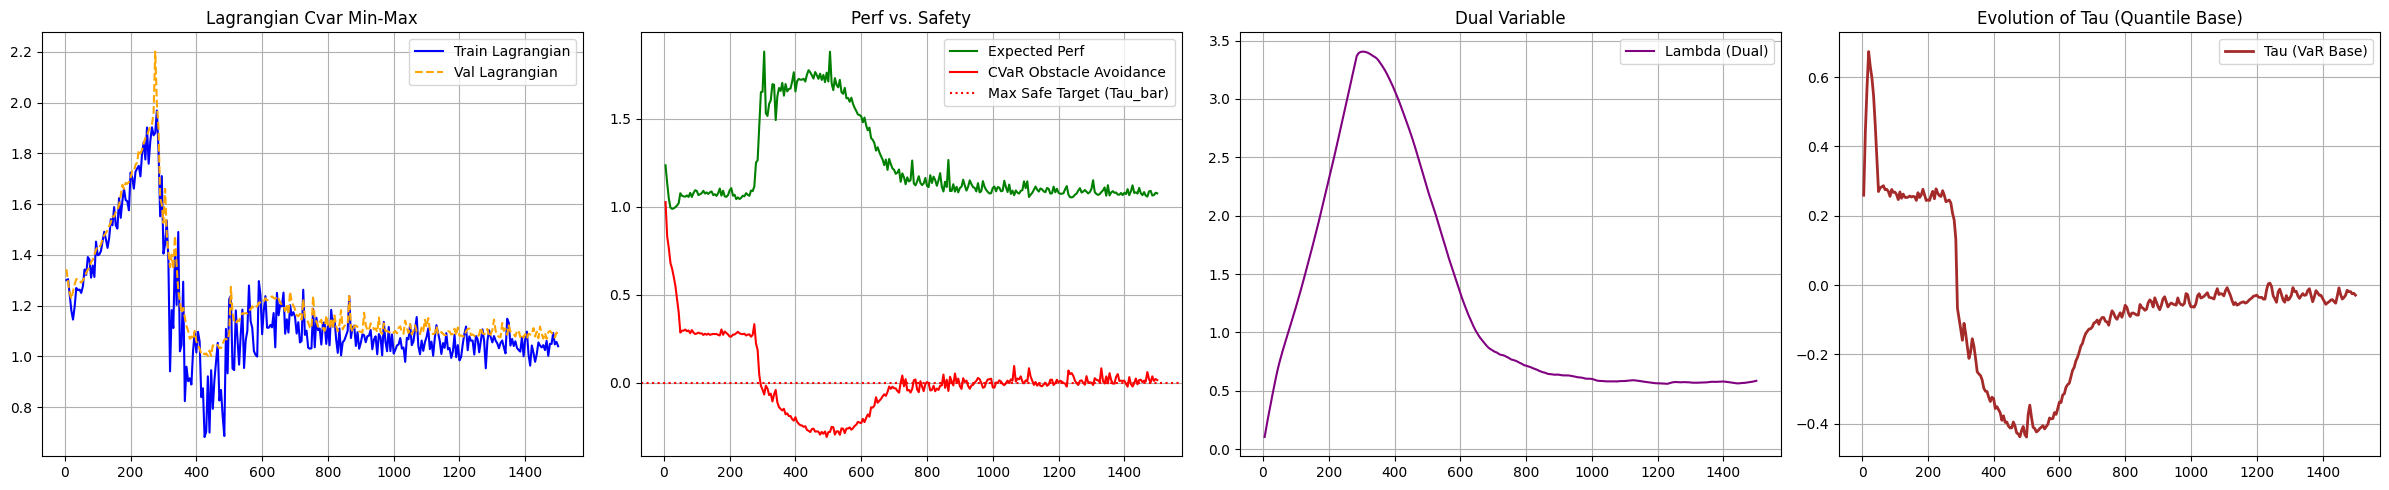

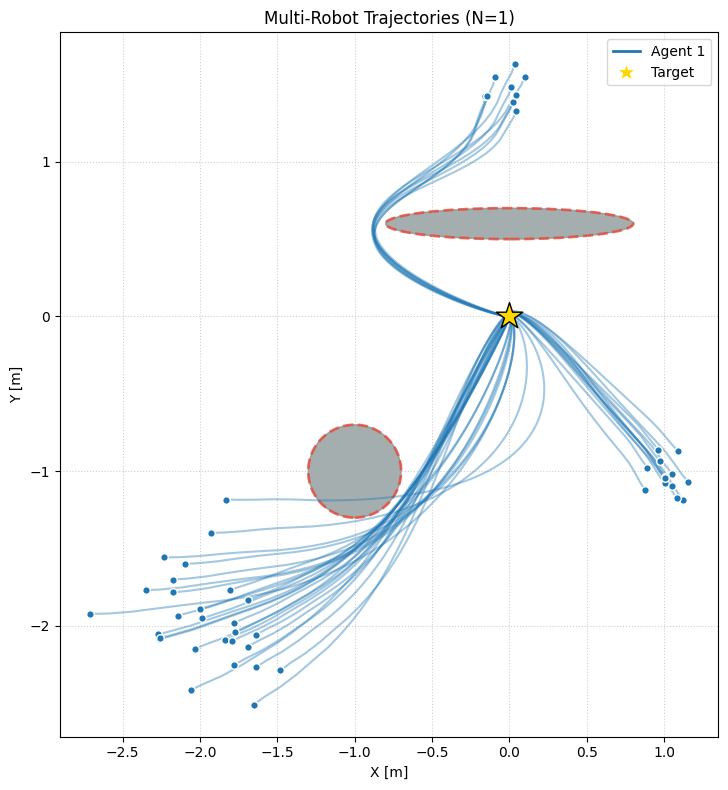

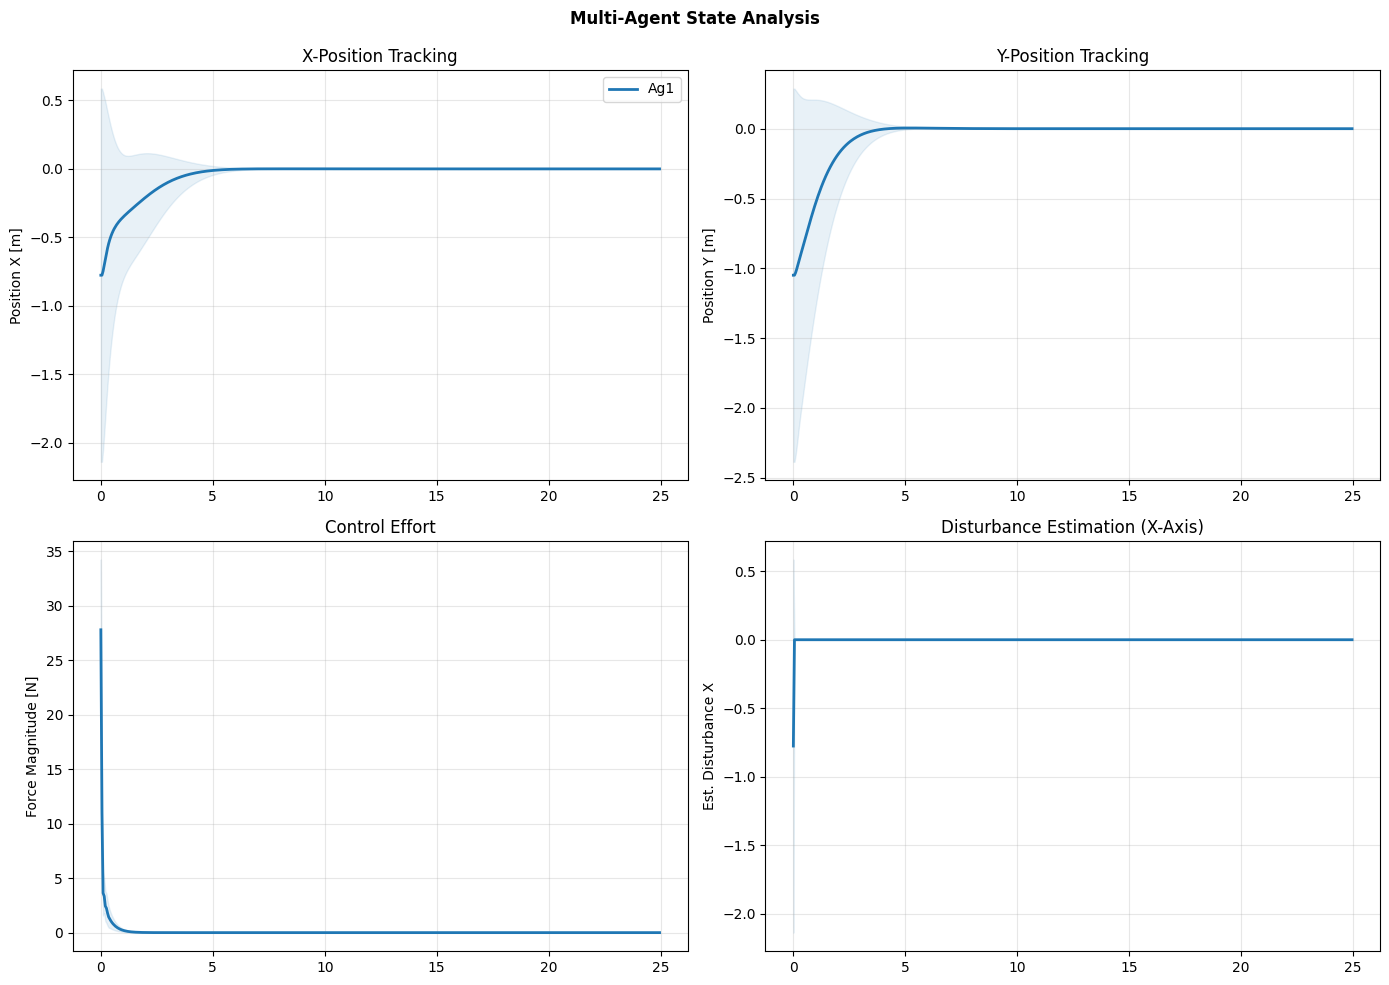

alpha=0.050 | mean_perf_qr=1.073220 | q95_violation=-0.047107 | violation_rate=1.20%
saved model: lagrangian_cvar_checkpoints/lagrangian_cvar_alpha_0p05.pt


In [4]:
run_lagrangian = run_cvar_lagrangian(alpha=alpha_lagrangian, seed_offset=11)

# Train ERM-RBF + Informed lambda_obs Search


Informed search 1/2: match mean_perf_qr to CVaR-Lagrangian
Training ERM-RBF with lambda_obs=50.0
Starting STANDARD_MSE online training on cpu...


Standard Mse: 100%|██████████| 1500/1500 [10:03<00:00,  2.49it/s, Val Loss=1.0512, Best=1.0483]



Restored best model (Metric: 1.0483).


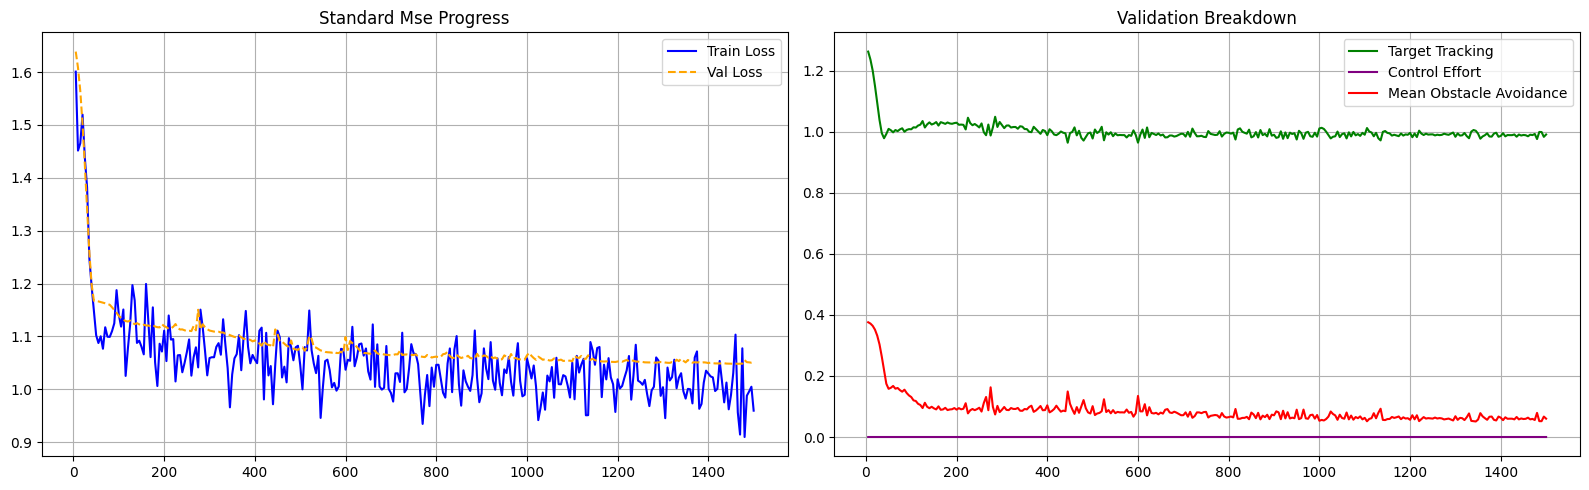

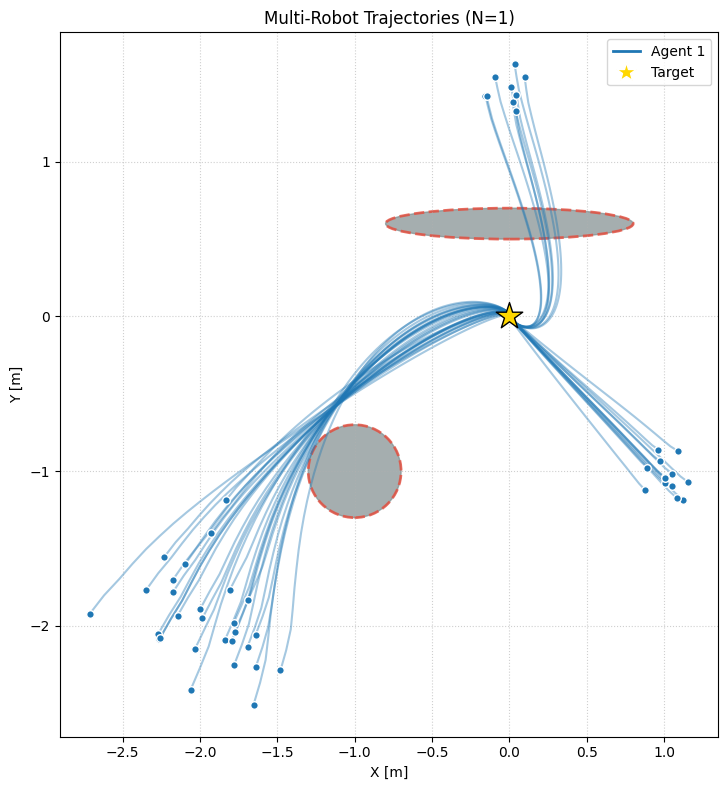

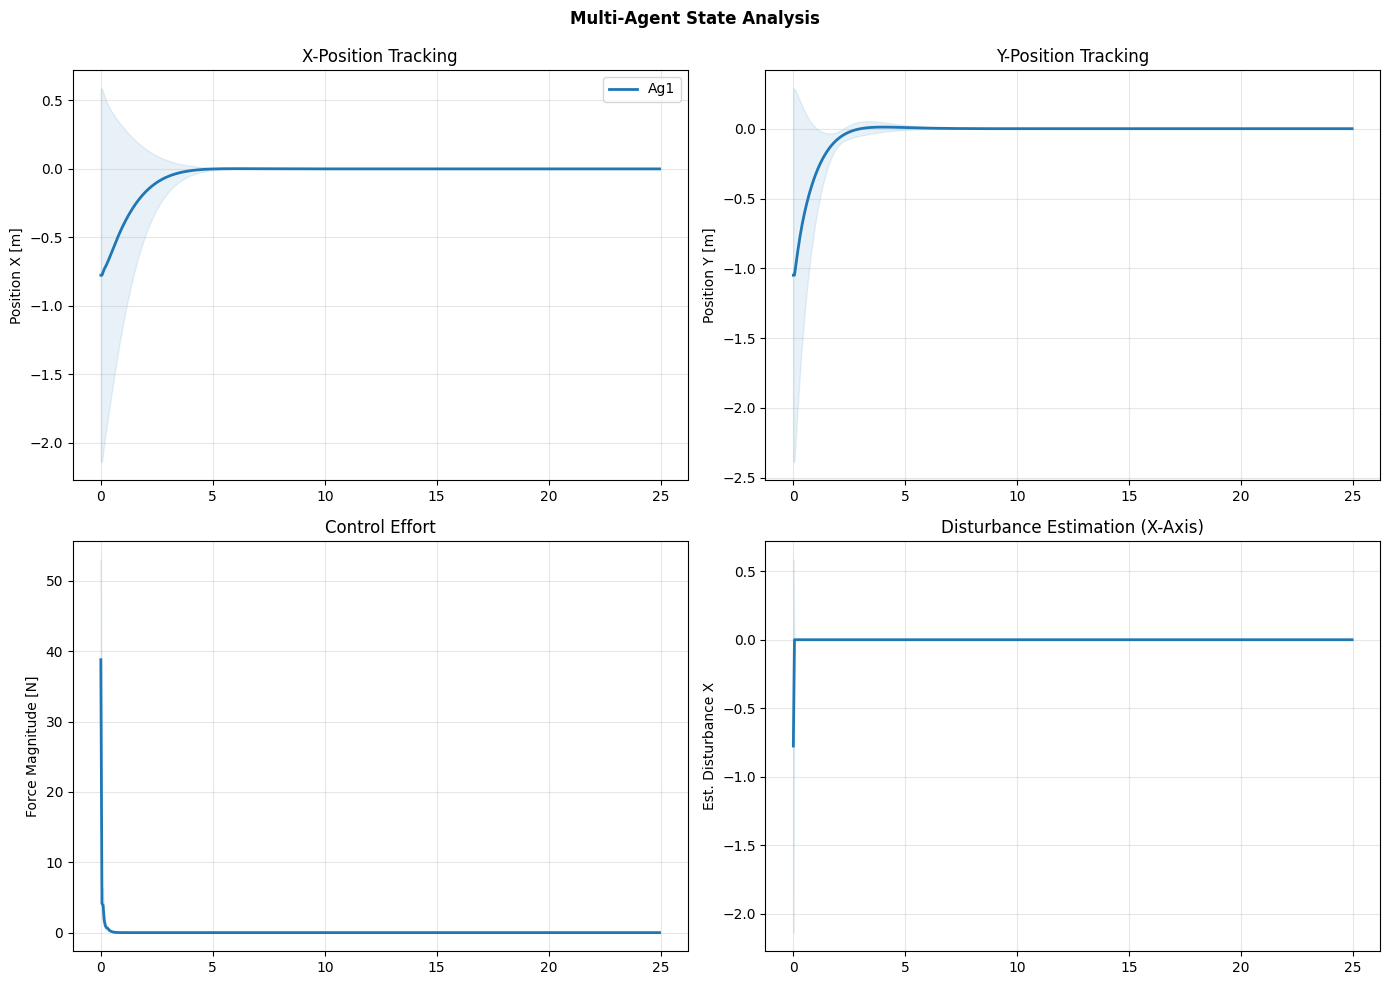

lambda_obs=50.000000 | mean_perf_qr=0.990459 | q95_violation=0.547113 | violation_rate=24.20%
saved model: erm_rbf_lambda_search_checkpoints/erm_rbf_lambda_50p000000.pt
[perf] iter=01 | lambda_obs=50.000000 | mean_perf_qr=0.990459 | target=1.073220 | gap=-0.082761
Training ERM-RBF with lambda_obs=80.0
Starting STANDARD_MSE online training on cpu...


Standard Mse: 100%|██████████| 1500/1500 [10:11<00:00,  2.45it/s, Val Loss=1.0893, Best=1.0891]



Restored best model (Metric: 1.0891).


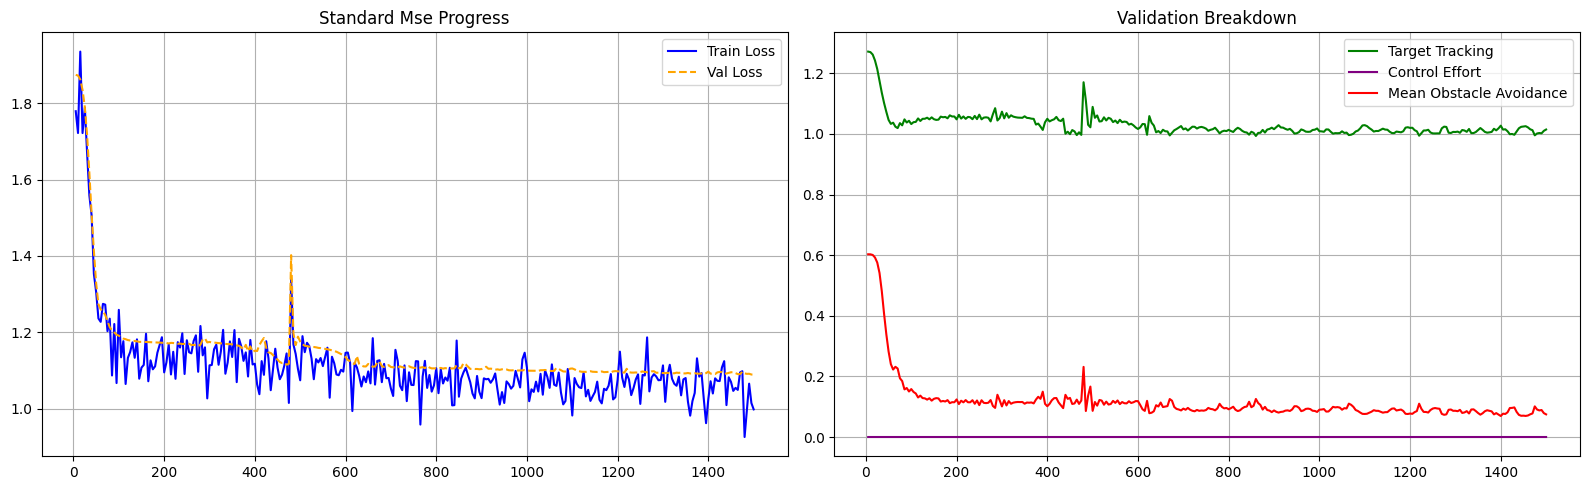

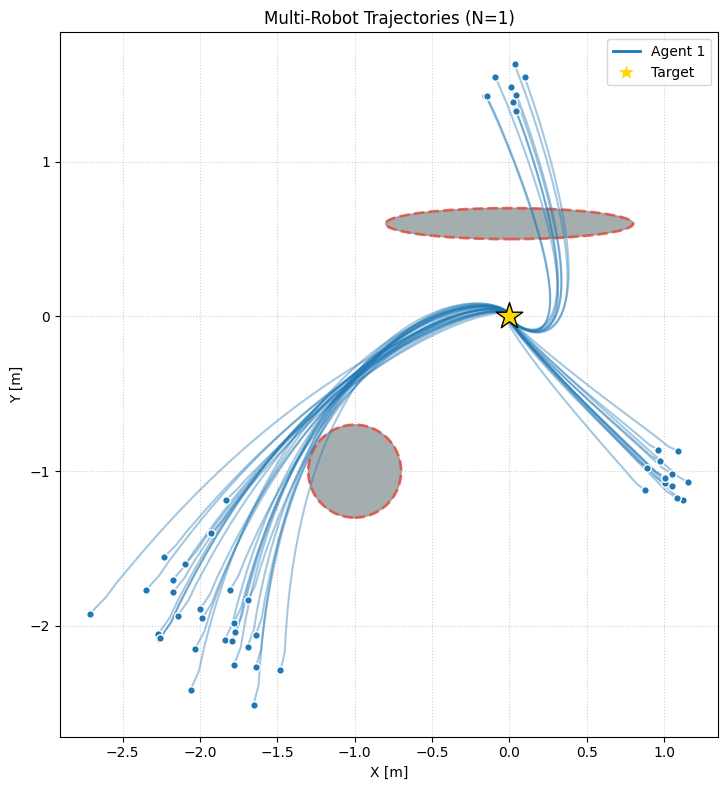

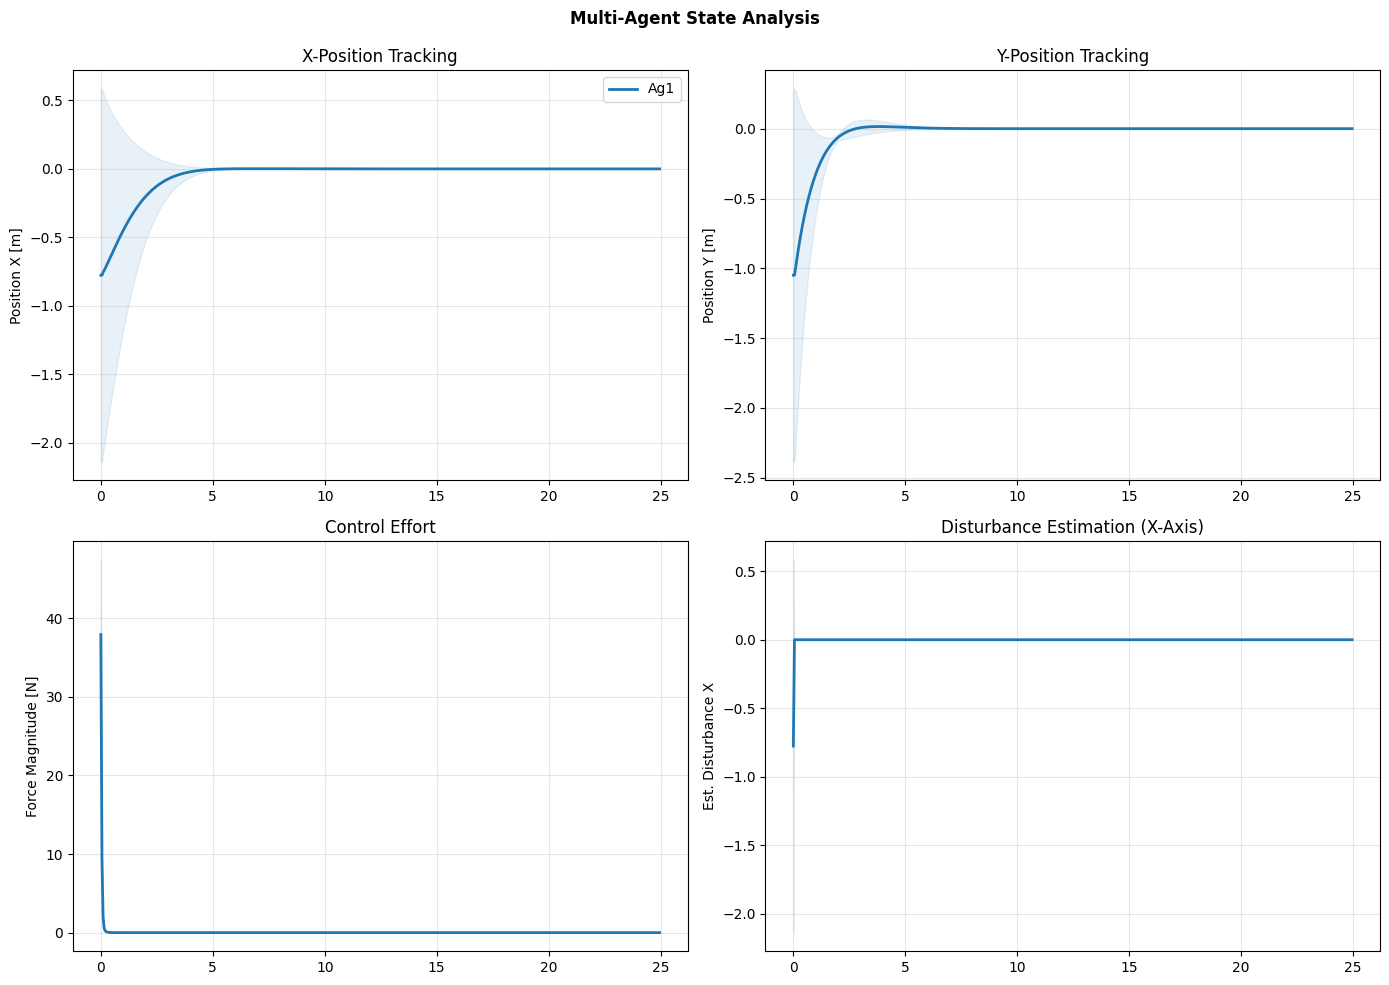

lambda_obs=80.000000 | mean_perf_qr=1.010255 | q95_violation=0.501600 | violation_rate=24.60%
saved model: erm_rbf_lambda_search_checkpoints/erm_rbf_lambda_80p000000.pt
[perf] iter=02 | lambda_obs=80.000000 | mean_perf_qr=1.010255 | target=1.073220 | gap=-0.062965
Training ERM-RBF with lambda_obs=128.0
Starting STANDARD_MSE online training on cpu...


Standard Mse: 100%|██████████| 1500/1500 [10:16<00:00,  2.43it/s, Val Loss=1.1092, Best=1.1097]



Restored best model (Metric: 1.1092).


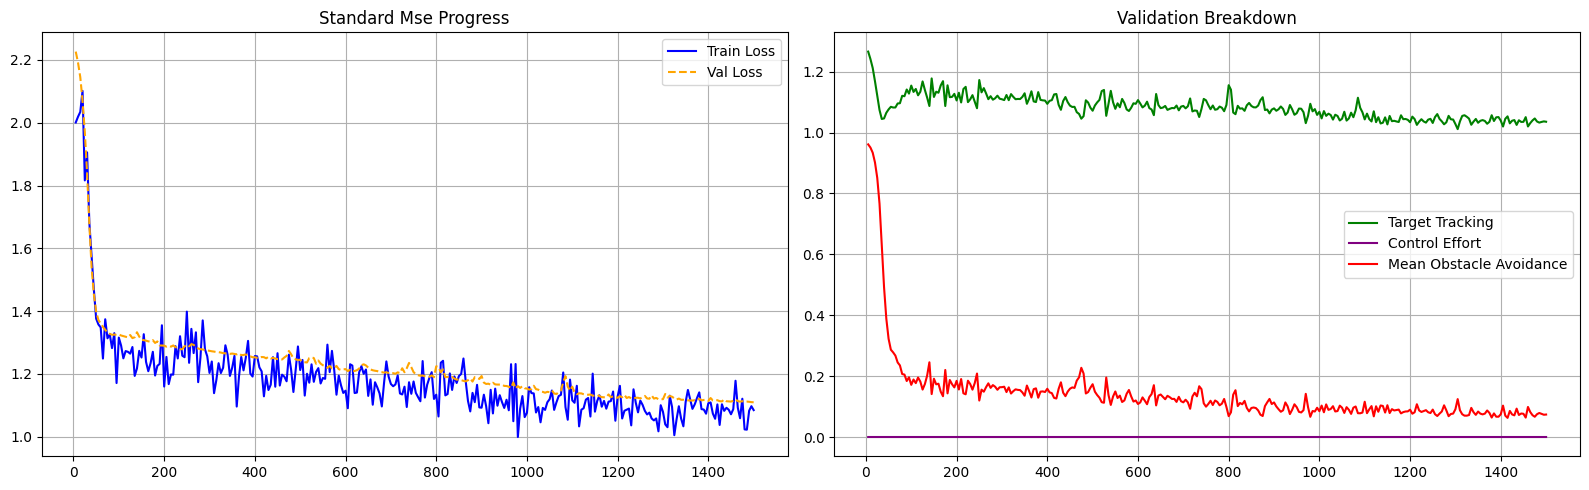

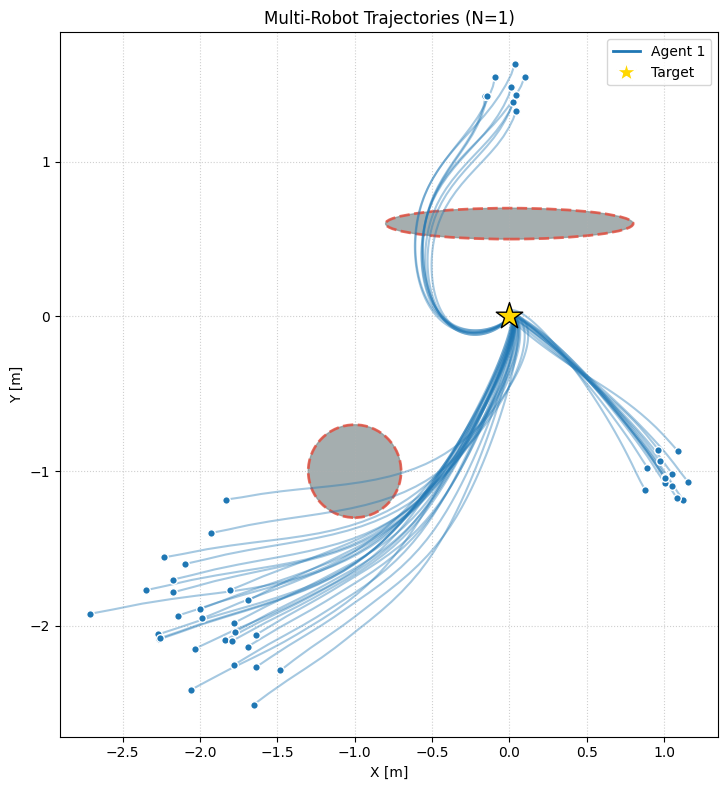

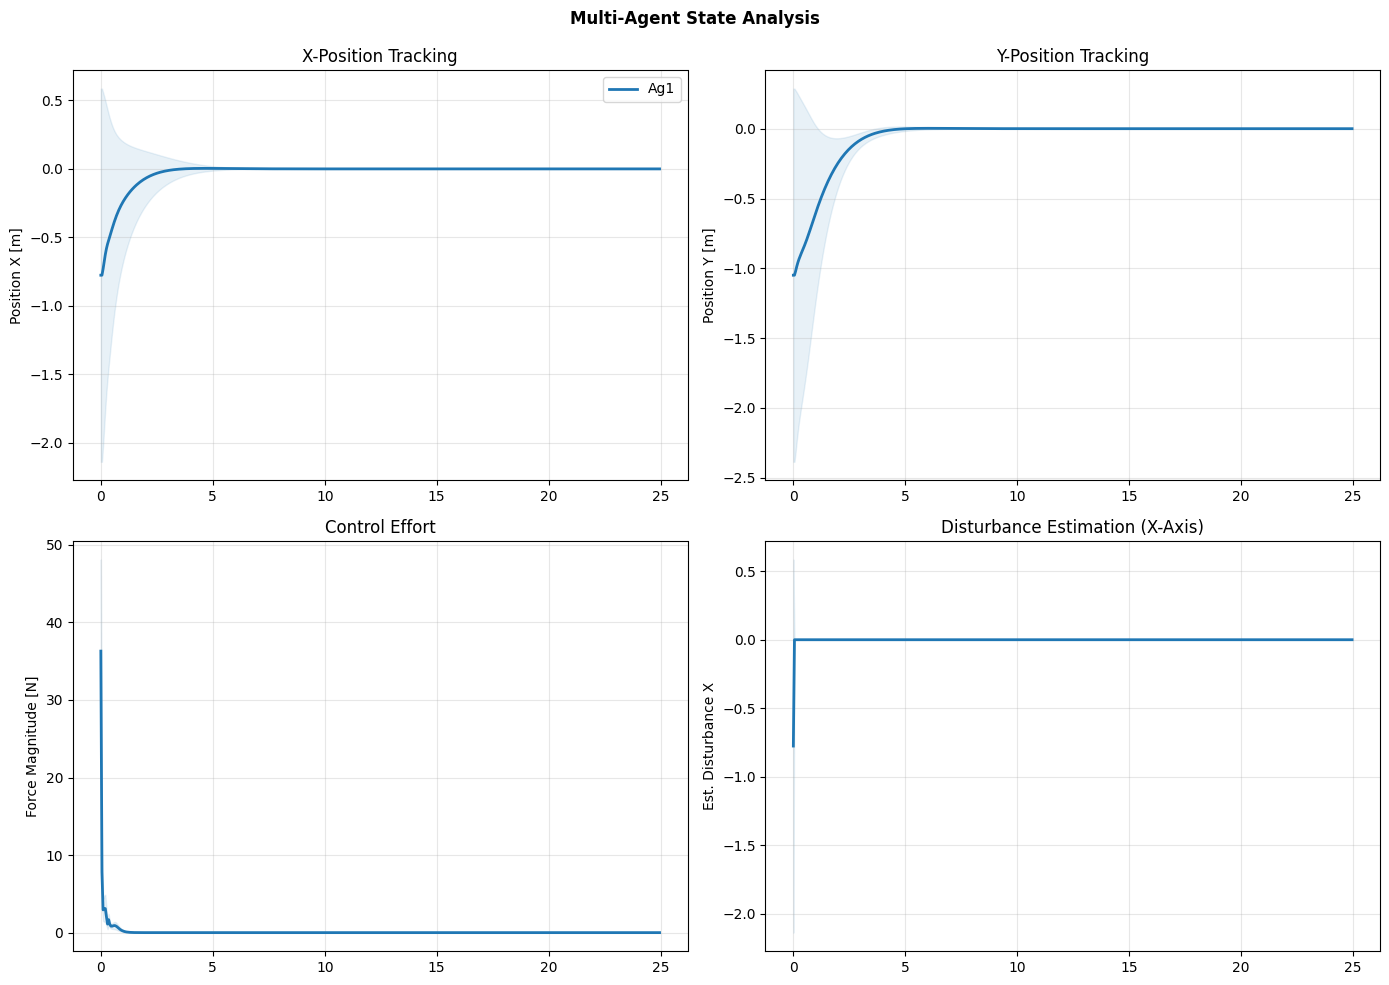

lambda_obs=128.000000 | mean_perf_qr=1.035399 | q95_violation=0.256354 | violation_rate=22.20%
saved model: erm_rbf_lambda_search_checkpoints/erm_rbf_lambda_128p000000.pt
[perf] iter=03 | lambda_obs=128.000000 | mean_perf_qr=1.035399 | target=1.073220 | gap=-0.037821
[perf] reached tolerance (<= 0.05).
[perf] best lambda_obs=128.000000 | mean_perf_qr=1.035399 | abs_gap=0.037821

Informed search 2/2: match violation_quantile_95 to CVaR-Lagrangian
Reusing existing ERM-RBF run for lambda_obs=128.000000
[viol] iter=01 | lambda_obs=128.000000 | violation_quantile_95=0.256354 | target=-0.047107 | gap=+0.303461
Training ERM-RBF with lambda_obs=204.8
Starting STANDARD_MSE online training on cpu...


Standard Mse: 100%|██████████| 1500/1500 [10:08<00:00,  2.46it/s, Val Loss=1.1567, Best=1.1538]



Restored best model (Metric: 1.1538).


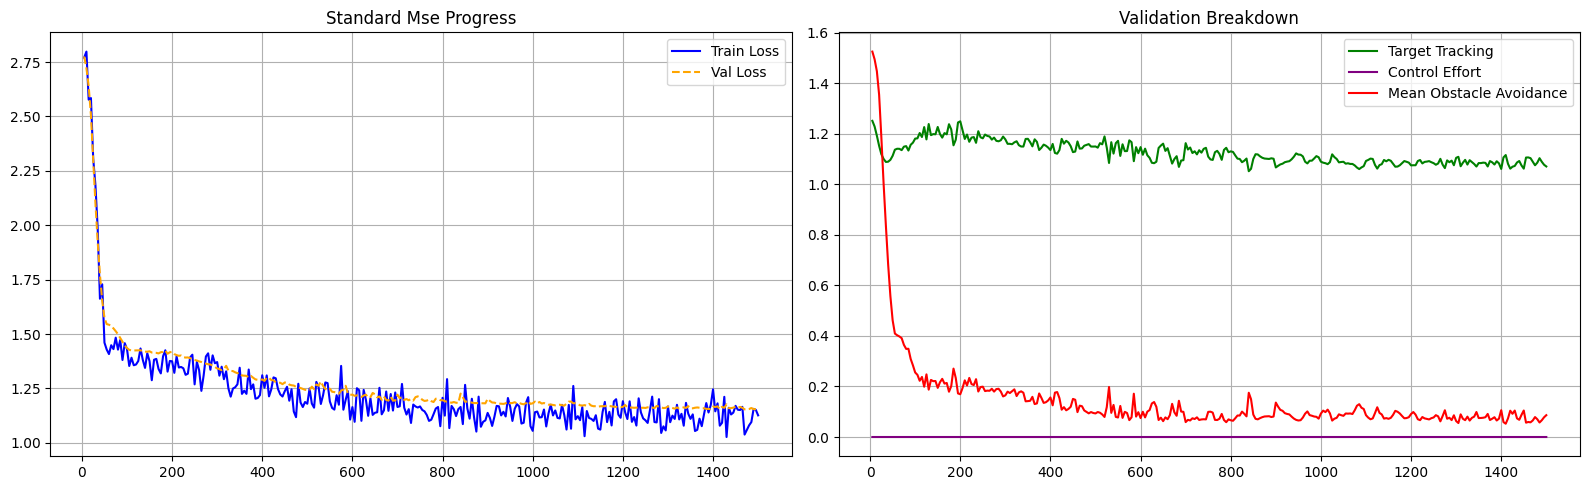

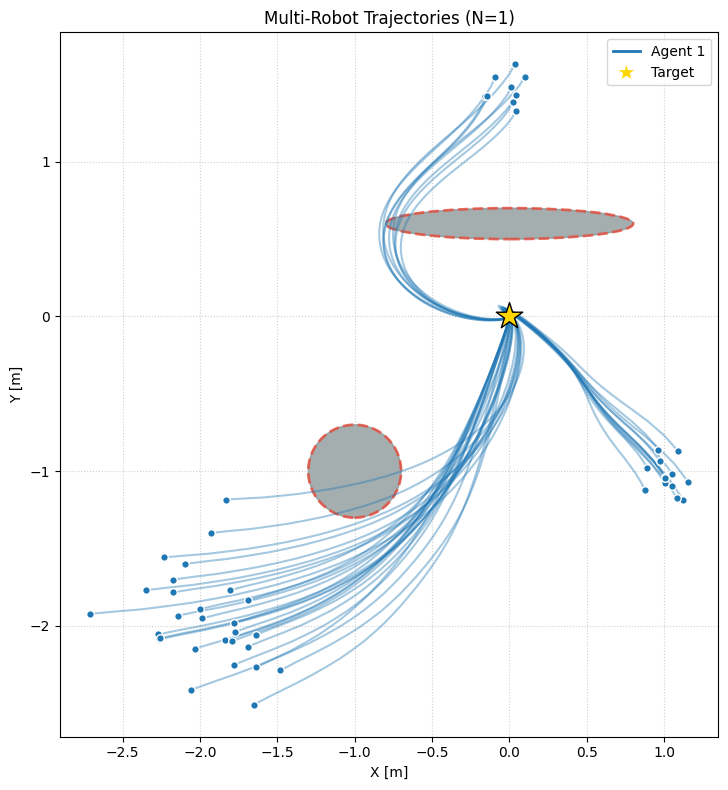

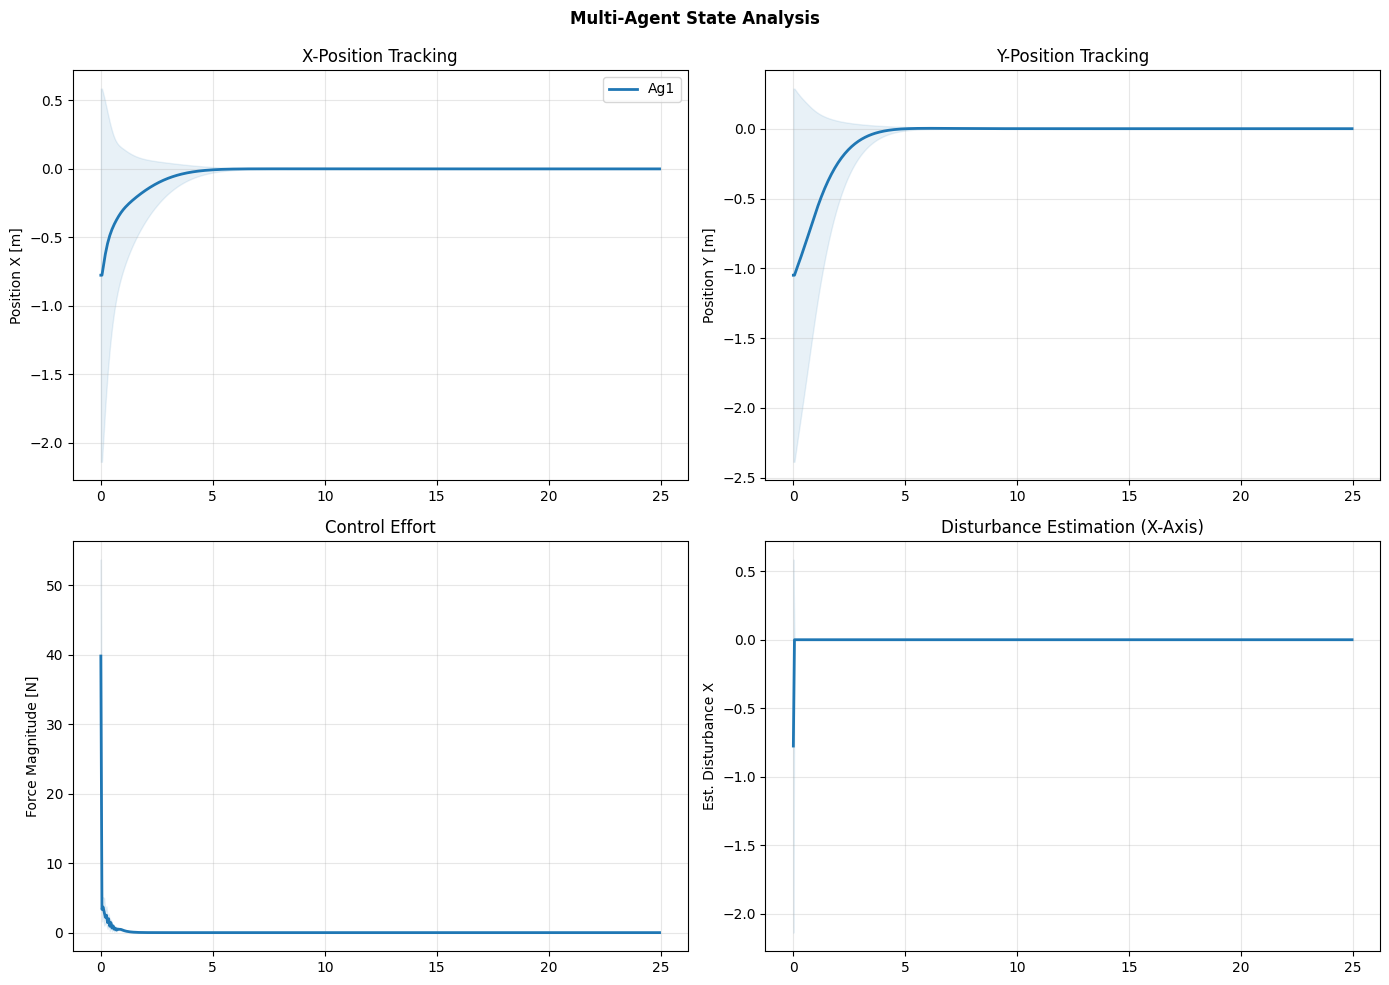

lambda_obs=204.800000 | mean_perf_qr=1.074961 | q95_violation=0.065967 | violation_rate=12.80%
saved model: erm_rbf_lambda_search_checkpoints/erm_rbf_lambda_204p800000.pt
[viol] iter=02 | lambda_obs=204.800000 | violation_quantile_95=0.065967 | target=-0.047107 | gap=+0.113073
Training ERM-RBF with lambda_obs=327.68
Starting STANDARD_MSE online training on cpu...


Standard Mse: 100%|██████████| 1500/1500 [09:56<00:00,  2.51it/s, Val Loss=1.2477, Best=1.2432]


Restored best model (Metric: 1.2432).


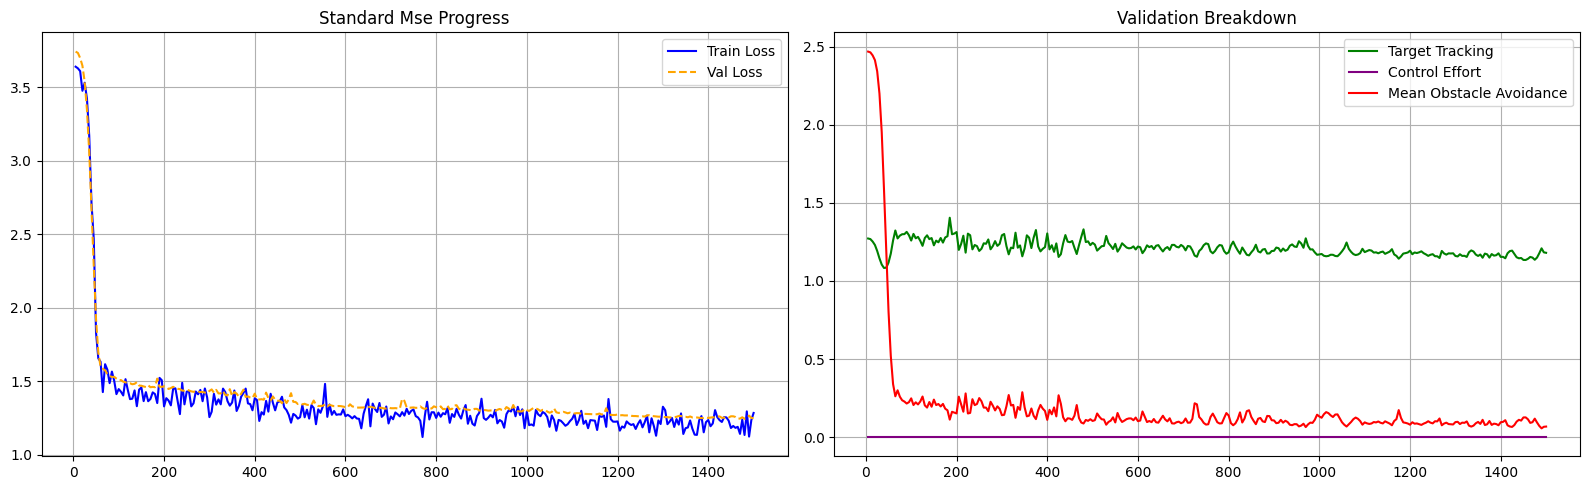

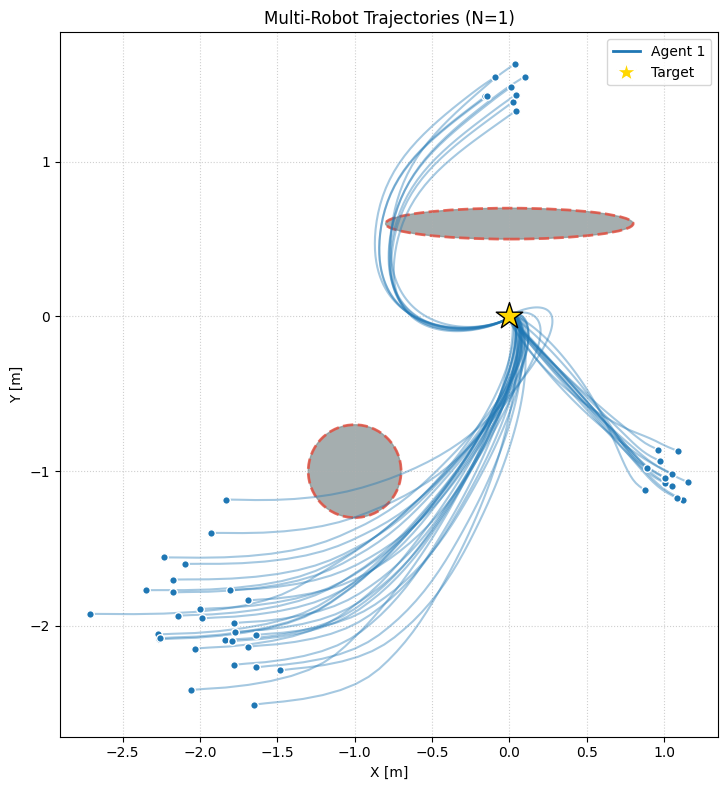

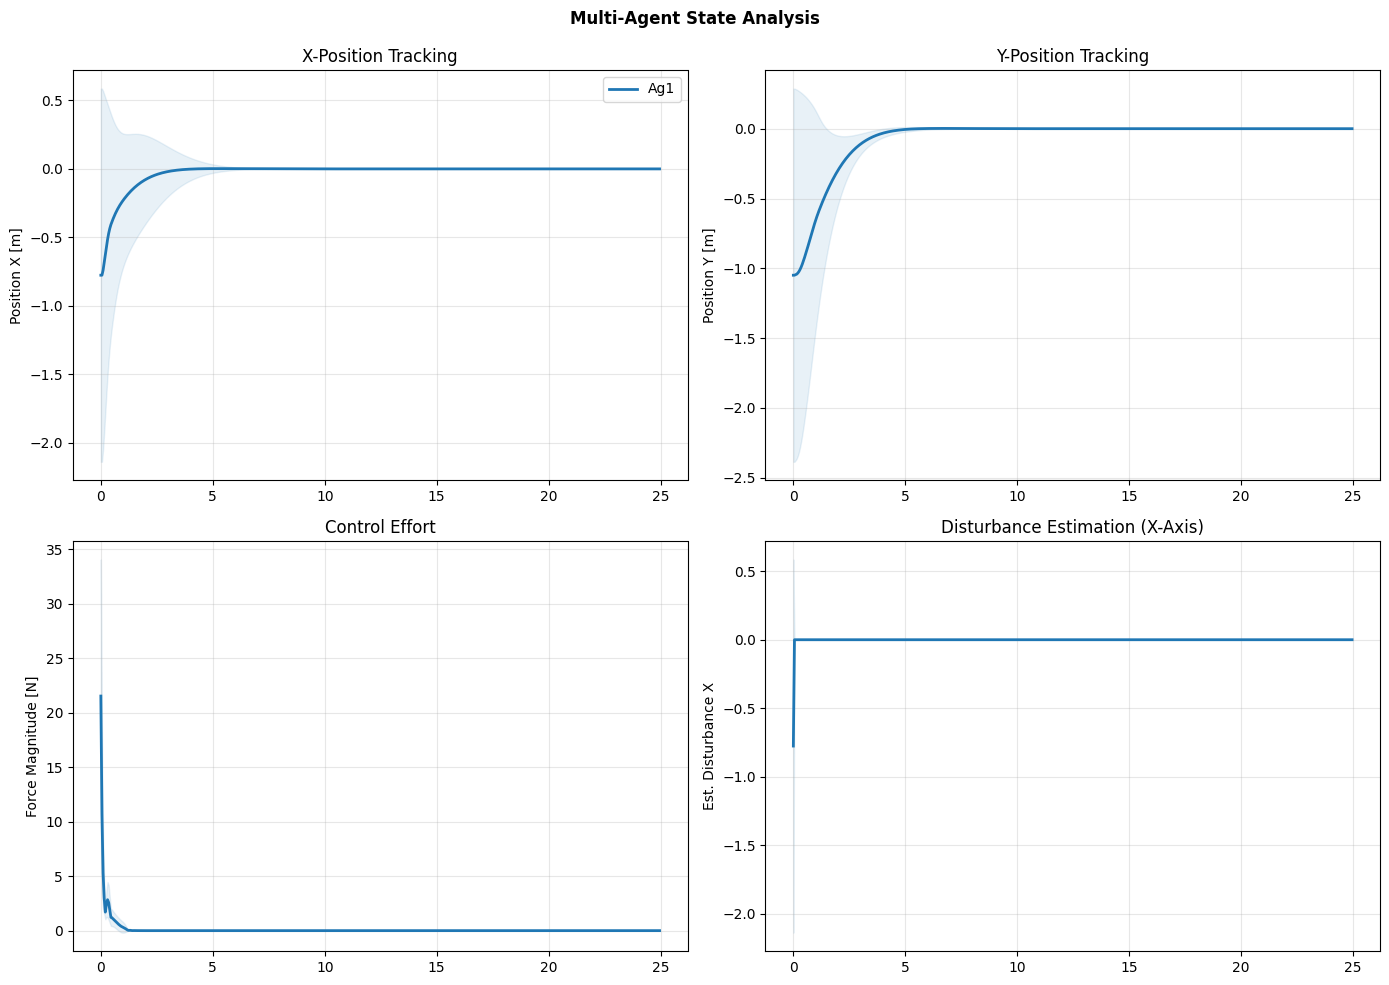

lambda_obs=327.680000 | mean_perf_qr=1.150191 | q95_violation=0.049625 | violation_rate=12.60%
saved model: erm_rbf_lambda_search_checkpoints/erm_rbf_lambda_327p680000.pt
[viol] iter=03 | lambda_obs=327.680000 | violation_quantile_95=0.049625 | target=-0.047107 | gap=+0.096732
Training ERM-RBF with lambda_obs=524.288
Starting STANDARD_MSE online training on cpu...


Standard Mse: 100%|██████████| 1500/1500 [09:50<00:00,  2.54it/s, Val Loss=1.4690, Best=1.4681]


Restored best model (Metric: 1.4681).


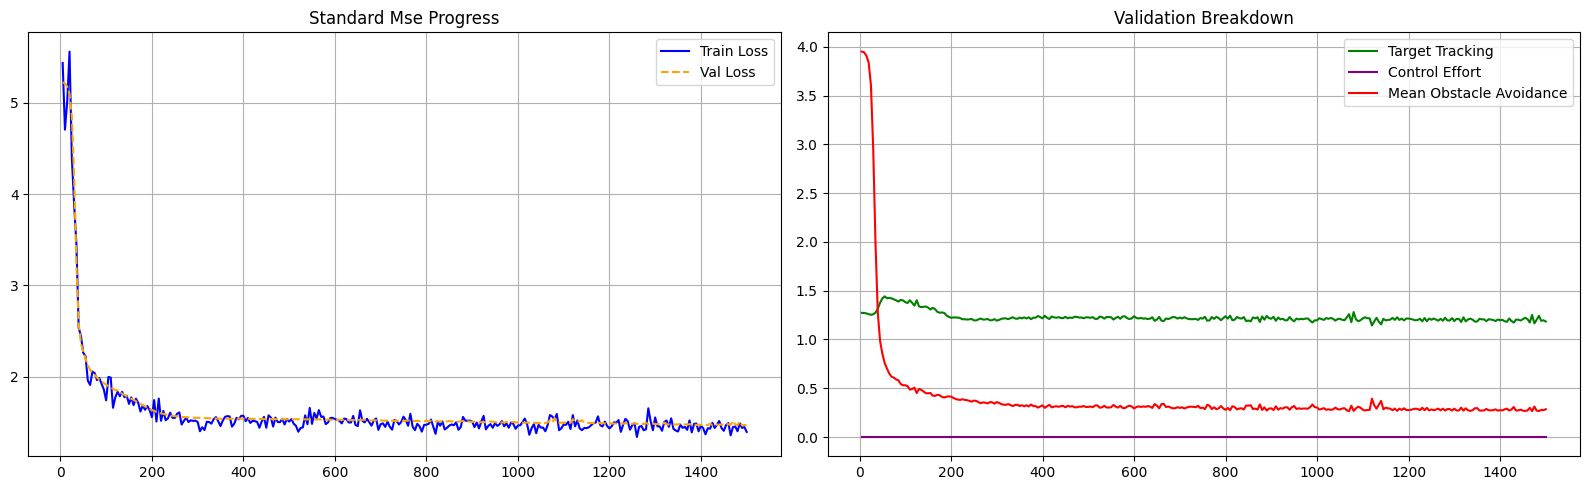

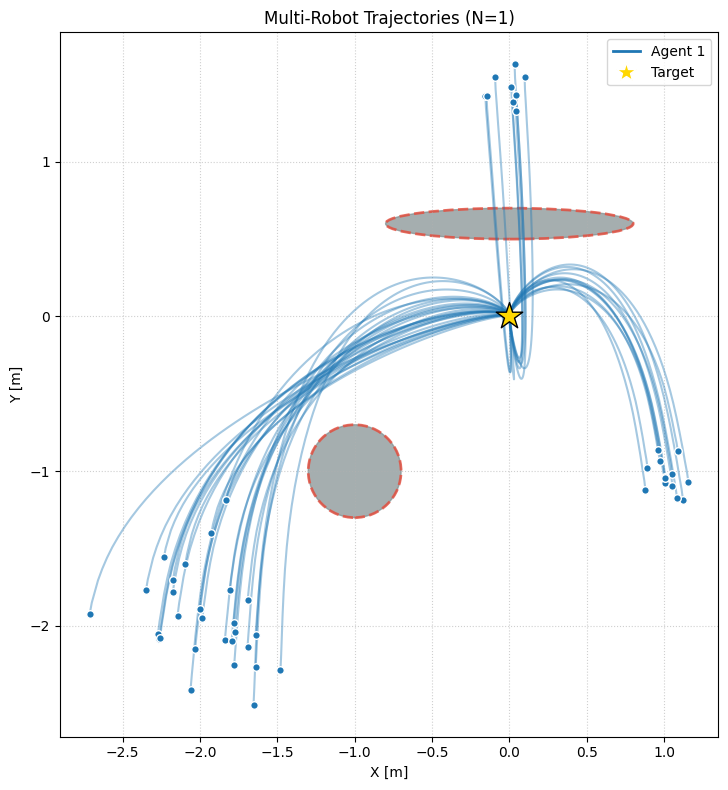

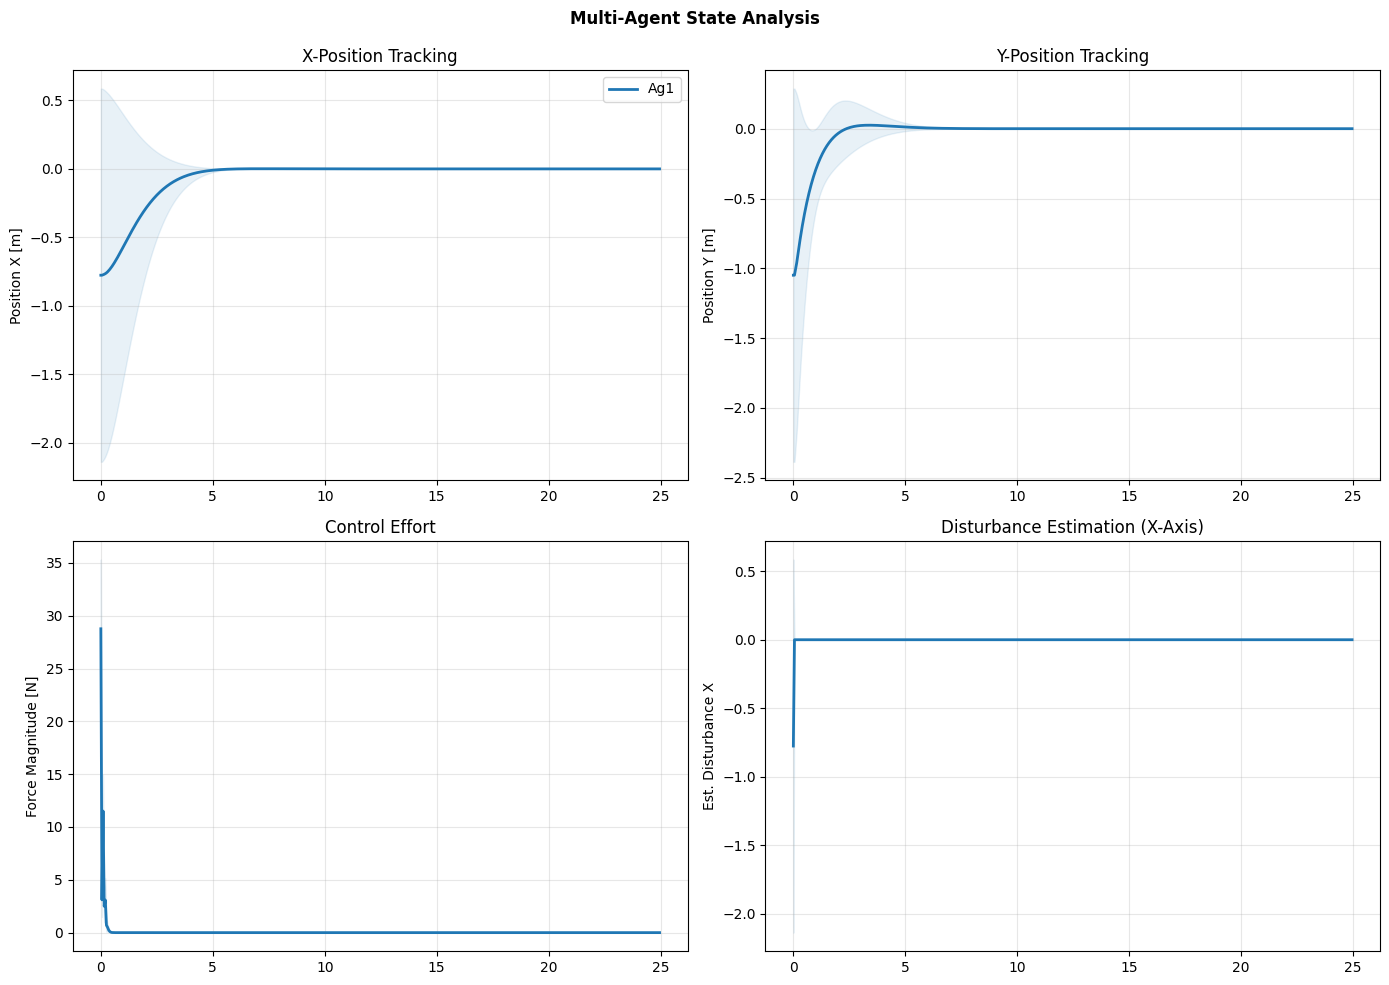

lambda_obs=524.288000 | mean_perf_qr=1.190915 | q95_violation=0.362308 | violation_rate=19.80%
saved model: erm_rbf_lambda_search_checkpoints/erm_rbf_lambda_524p288000.pt
[viol] iter=04 | lambda_obs=524.288000 | violation_quantile_95=0.362308 | target=-0.047107 | gap=+0.409415
Training ERM-RBF with lambda_obs=838.8608
Starting STANDARD_MSE online training on cpu...


Standard Mse: 100%|██████████| 1500/1500 [09:54<00:00,  2.52it/s, Val Loss=1.3018, Best=1.3109]



Restored best model (Metric: 1.3018).


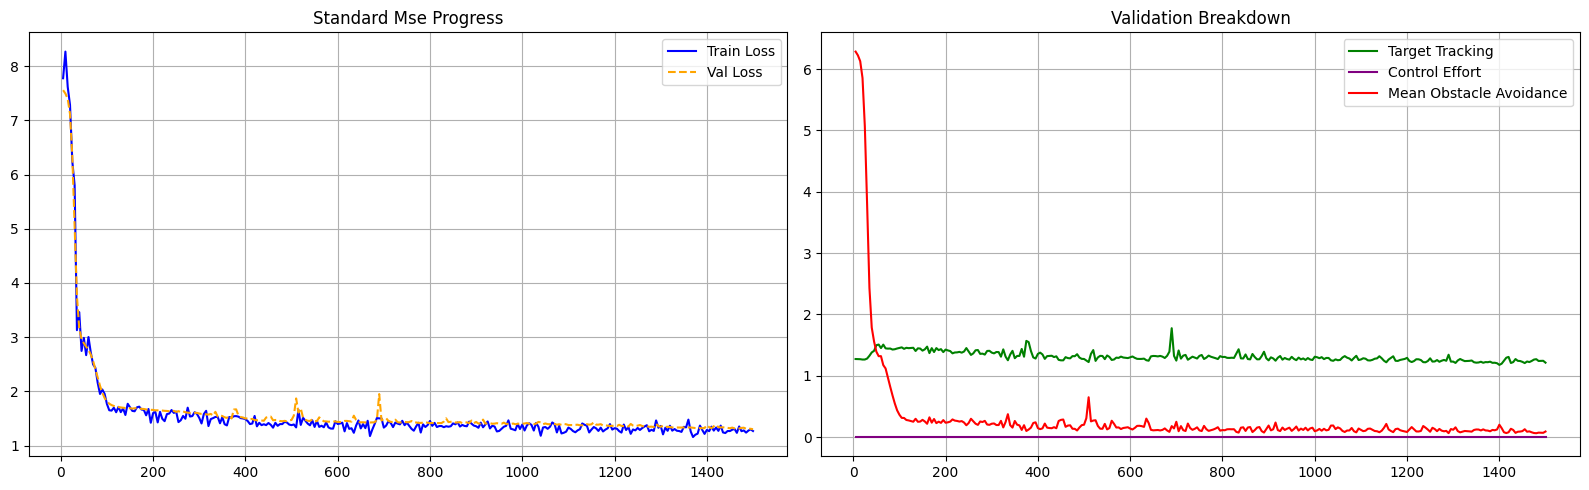

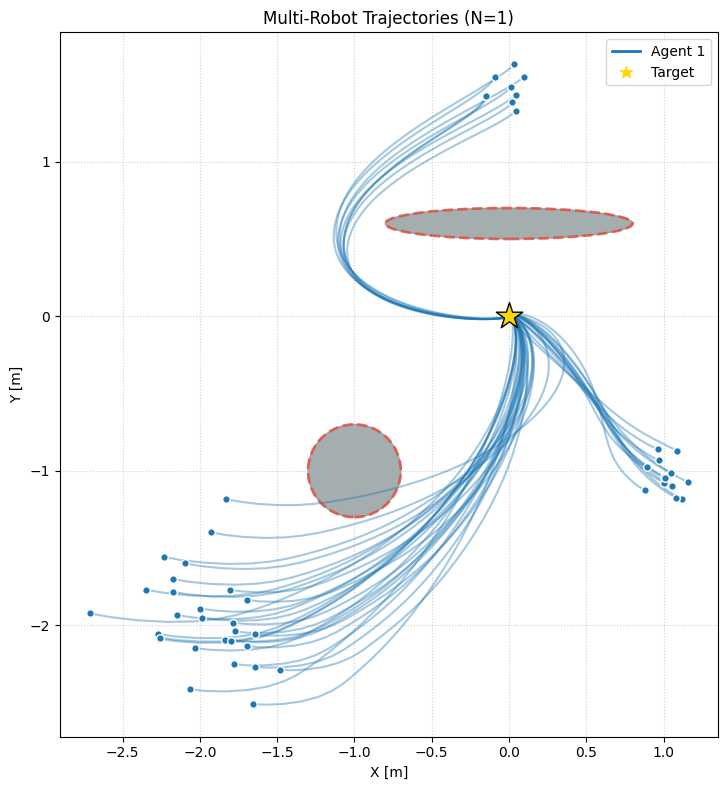

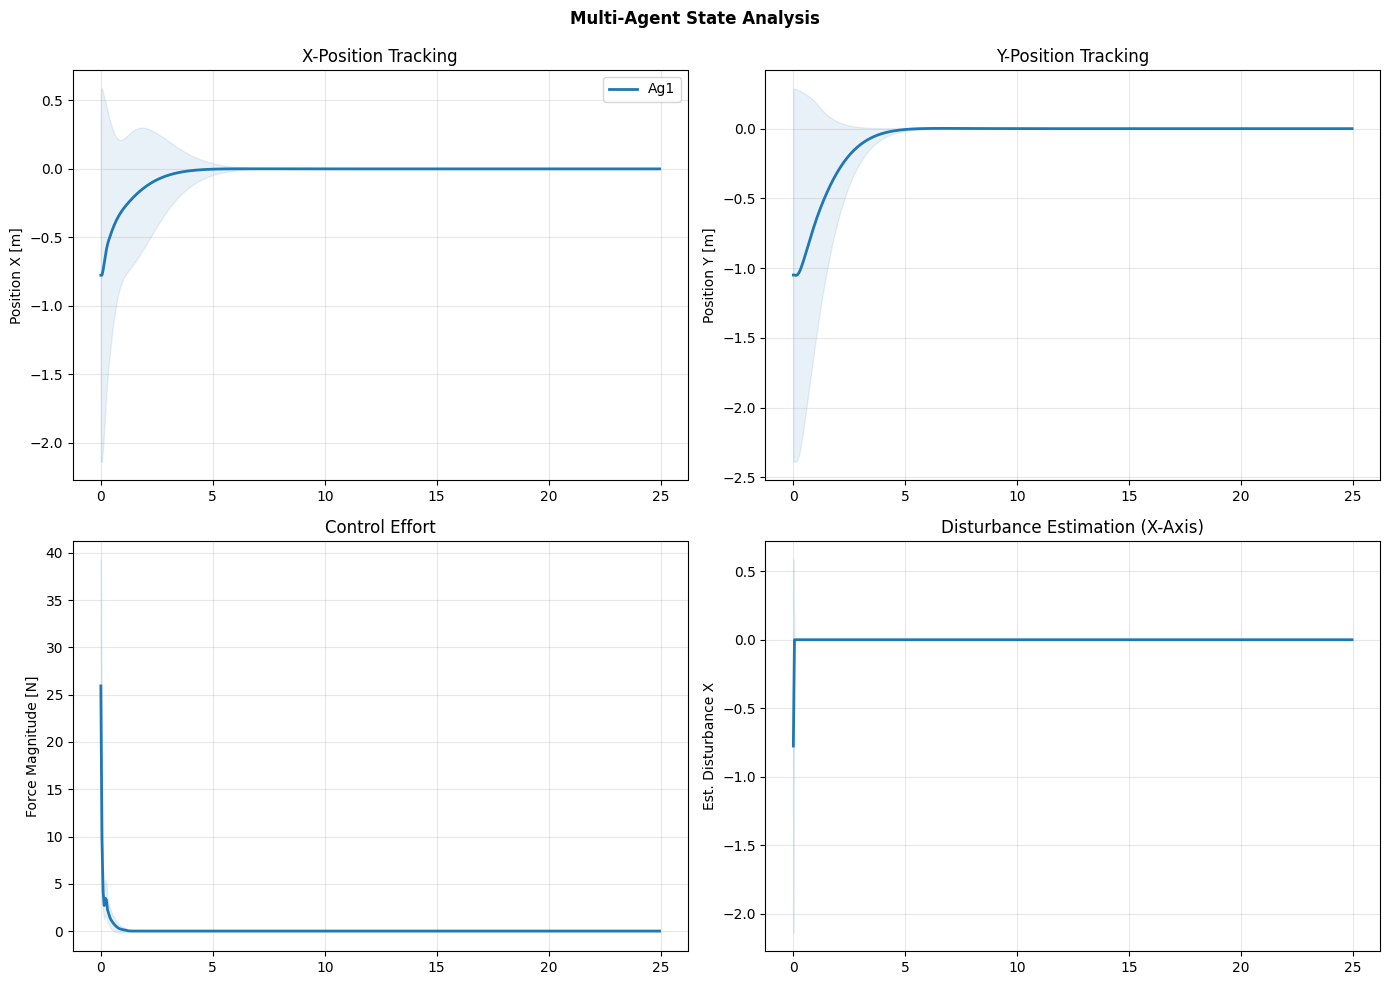

lambda_obs=838.860800 | mean_perf_qr=1.212326 | q95_violation=-0.134742 | violation_rate=1.00%
saved model: erm_rbf_lambda_search_checkpoints/erm_rbf_lambda_838p860800.pt
[viol] iter=05 | lambda_obs=838.860800 | violation_quantile_95=-0.134742 | target=-0.047107 | gap=-0.087635
[viol] sign flip detected — stopping to avoid oscillation.
[viol] best lambda_obs=838.860800 | violation_quantile_95=-0.134742 | abs_gap=0.087635

Informed search complete.
Best perf-match lambda_obs: 128.000000
Best viol-q95-match lambda_obs: 838.860800


In [5]:
if runs["lagrangian"] is None:
    raise RuntimeError("Run the CVaR-Lagrangian training cell first.")

lag_metrics = runs["lagrangian"]["metrics"]
target_perf = lag_metrics["mean_perf_qr"]
target_viol_q95 = lag_metrics["violation_quantile_95"]

print("\n" + "=" * 100)
print("Informed search 1/2: match mean_perf_qr to CVaR-Lagrangian")
best_perf_row, perf_trace = informed_search_lambda(
    target_value=target_perf,
    metric_key="mean_perf_qr",
    tolerance=mean_qr_tolerance,
    initial_lambda=initial_lambda_obs,
    max_iters=max_perf_search_iters,
    seed_start=1000,
    search_name="perf",
)
search_history["perf"] = perf_trace

print("\n" + "=" * 100)
print("Informed search 2/2: match violation_quantile_95 to CVaR-Lagrangian")
best_viol_row, viol_trace = informed_search_lambda(
    target_value=target_viol_q95,
    metric_key="violation_quantile_95",
    tolerance=violation_rate_tolerance,
    initial_lambda=best_perf_row["lambda_obs"],
    max_iters=max_viol_search_iters,
    seed_start=2000,
    search_name="viol",
)
search_history["viol"] = viol_trace

print("\nInformed search complete.")
print(f"Best perf-match lambda_obs: {best_perf_row['lambda_obs']:.6f}")
print(f"Best viol-q95-match lambda_obs: {best_viol_row['lambda_obs']:.6f}")

## ERM-RBF Lambda Search Results

### Select Two ERM Models from Informed Search

In [6]:
if runs["lagrangian"] is None:
    raise RuntimeError("Run the CVaR-Lagrangian training cell first.")
if len(runs["erm_by_lambda"]) == 0:
    raise RuntimeError("Run the informed ERM lambda search cell first.")

lag_metrics = runs["lagrangian"]["metrics"]
target_perf = lag_metrics["mean_perf_qr"]
target_violation_q95 = lag_metrics["violation_quantile_95"]

erm_candidates = []
for lam, run in runs["erm_by_lambda"].items():
    m = run["metrics"]
    erm_candidates.append({
        "lambda_obs": lam,
        "run": run,
        "mean_perf_qr": m["mean_perf_qr"],
        "violation_rate": m["violation_rate"],
        "violation_quantile_95": m["violation_quantile_95"],
        "perf_gap": abs(m["mean_perf_qr"] - target_perf),
        "viol_gap": abs(m["violation_quantile_95"] - target_violation_q95),
    })

erm_candidates = sorted(erm_candidates, key=lambda d: d["lambda_obs"])
best_perf = min(erm_candidates, key=lambda d: d["perf_gap"])
best_viol = min(erm_candidates, key=lambda d: d["viol_gap"])

# Prefer two distinct ERM models when possible.
if best_perf["lambda_obs"] == best_viol["lambda_obs"] and len(erm_candidates) > 1:
    best_viol = min(
        [c for c in erm_candidates if c["lambda_obs"] != best_perf["lambda_obs"]],
        key=lambda d: d["viol_gap"]
    )

selected_erm = {
    "perf_matched": best_perf,
    "viol_matched": best_viol,
}

print("Lagrangian targets on validation set:")
print(
    f"mean_perf_qr={target_perf:.6f} | viol_q95={target_violation_q95:.6f} | "
    f"violation_rate={lag_metrics['violation_rate']:.2%}"
)

print("\nERM candidates gathered by informed search (validation set):")
print("-" * 120)
print(f"{'lambda_obs':>12} | {'mean_perf_qr':>14} | {'viol_rate':>10} | {'viol_q95':>12} | {'|d_perf|':>12} | {'|d_viol_q95|':>12}")
print("-" * 120)
for row in erm_candidates:
    print(
        f"{row['lambda_obs']:>12.6f} | {row['mean_perf_qr']:>14.6f} | "
        f"{row['violation_rate']:>9.2%} | {row['violation_quantile_95']:>12.6f} | "
        f"{row['perf_gap']:>12.6f} | {row['viol_gap']:>12.6f}"
    )
print("-" * 120)

print("\nSelected ERM models:")
print(
    f"perf-matched: lambda_obs={selected_erm['perf_matched']['lambda_obs']:.6f} | "
    f"mean_perf_qr={selected_erm['perf_matched']['mean_perf_qr']:.6f} | "
    f"viol_q95={selected_erm['perf_matched']['violation_quantile_95']:.6f}"
)
print(
    f"viol-q95-matched: lambda_obs={selected_erm['viol_matched']['lambda_obs']:.6f} | "
    f"mean_perf_qr={selected_erm['viol_matched']['mean_perf_qr']:.6f} | "
    f"viol_q95={selected_erm['viol_matched']['violation_quantile_95']:.6f}"
)

if search_history["perf"]:
    print("\nPerf-search trace:")
    for row in search_history["perf"]:
        print(
            f"  iter={row['iter']:>2d} | lambda={row['lambda_obs']:.6f} | "
            f"mean_perf_qr={row['metric']:.6f} | gap={row['gap']:+.6f}"
        )

if search_history["viol"]:
    print("\nViolation-search trace:")
    for row in search_history["viol"]:
        print(
            f"  iter={row['iter']:>2d} | lambda={row['lambda_obs']:.6f} | "
            f"violation_quantile_95={row['metric']:.6f} | gap={row['gap']:+.6f}"
        )

Lagrangian targets on validation set:
mean_perf_qr=1.073220 | viol_q95=-0.047107 | violation_rate=1.20%

ERM candidates gathered by informed search (validation set):
------------------------------------------------------------------------------------------------------------------------
  lambda_obs |   mean_perf_qr |  viol_rate |     viol_q95 |     |d_perf| | |d_viol_q95|
------------------------------------------------------------------------------------------------------------------------
   50.000000 |       0.990459 |    24.20% |     0.547113 |     0.082761 |     0.594219
   80.000000 |       1.010255 |    24.60% |     0.501600 |     0.062965 |     0.548706
  128.000000 |       1.035399 |    22.20% |     0.256354 |     0.037821 |     0.303461
  204.800000 |       1.074961 |    12.80% |     0.065967 |     0.001742 |     0.113073
  327.680000 |       1.150191 |    12.60% |     0.049625 |     0.076972 |     0.096732
  524.288000 |       1.190915 |    19.80% |     0.362308 |     0.1176

# Final Comparison on Independent Calibration Set + Pareto Curve

## Load Models

In [7]:
# Load models
import glob
import torch

if "alpha_lagrangian" not in globals():
    alpha_lagrangian = 0.05
if "save_dir_lagrangian" not in globals():
    save_dir_lagrangian = "lagrangian_cvar_checkpoints"
if "save_dir_erm" not in globals():
    save_dir_erm = "erm_rbf_lambda_search_checkpoints"
if "runs" not in globals() or not isinstance(runs, dict):
    runs = {"lagrangian": None, "erm_by_lambda": {}}
if "base_cfg" not in globals():
    base_cfg = ExperimentConfig(alpha_train=alpha_lagrangian)

def load_sim_state_compat(sim, ckpt_state_dict, tag: str):
    """Load only compatible tensor entries from a checkpoint state_dict."""
    current_state = sim.state_dict()
    filtered_state = {}
    skipped_unexpected = []
    skipped_shape = []

    for k, v in ckpt_state_dict.items():
        if k not in current_state:
            skipped_unexpected.append(k)
            continue
        if current_state[k].shape != v.shape:
            skipped_shape.append((k, tuple(v.shape), tuple(current_state[k].shape)))
            continue
        filtered_state[k] = v

    missing_keys, unexpected_keys = sim.load_state_dict(filtered_state, strict=False)

    if skipped_unexpected:
        print(f"[{tag}] skipped unexpected keys ({len(skipped_unexpected)}): {skipped_unexpected}")
    if skipped_shape:
        print(f"[{tag}] skipped shape-mismatched keys ({len(skipped_shape)}):")
        for name, src_shape, dst_shape in skipped_shape:
            print(f"  - {name}: ckpt={src_shape}, model={dst_shape}")
    if missing_keys:
        print(f"[{tag}] missing keys after partial load ({len(missing_keys)}).")
    if unexpected_keys:
        print(f"[{tag}] unexpected keys after partial load ({len(unexpected_keys)}).")

# ── Reload CVaR-Lagrangian ───────────────────────────────────────────────────
lag_ckpt_files = sorted(glob.glob(f"{save_dir_lagrangian}/lagrangian_cvar_alpha_*.pt"))
if not lag_ckpt_files:
    raise RuntimeError(f"No Lagrangian checkpoint found in {save_dir_lagrangian}/")

lag_ckpt = torch.load(lag_ckpt_files[-1], map_location=base_cfg.device)
lag_cfg = ExperimentConfig(alpha_train=lag_ckpt["alpha_train"])
lag_sim, lag_metric, lag_wrapper = build_training_objects(lag_cfg)
load_sim_state_compat(lag_sim, lag_ckpt["sim_state_dict"], tag="lagrangian")
lag_sim.eval()

runs["lagrangian"] = {
    "label": "CVaR Lagrangian",
    "config": lag_cfg,
    "sim": lag_sim,
    "metric": lag_metric,
    "metrics": lag_ckpt["metrics"],
    "ckpt_path": lag_ckpt_files[-1],
}
print(f"Loaded Lagrangian checkpoint: {lag_ckpt_files[-1]}")

# ── Reload all ERM-RBF checkpoints ──────────────────────────────────────────
erm_ckpt_files = sorted(glob.glob(f"{save_dir_erm}/erm_rbf_lambda_*.pt"))
if not erm_ckpt_files:
    raise RuntimeError(f"No ERM-RBF checkpoints found in {save_dir_erm}/")

runs["erm_by_lambda"] = {}
for ckpt_path in erm_ckpt_files:
    ckpt = torch.load(ckpt_path, map_location=base_cfg.device)
    lam = float(ckpt["lambda_obs"])
    cfg = ExperimentConfig(alpha_train=alpha_lagrangian, coll_mode="rbf", lambda_obs=lam)
    sim, metric, _ = build_training_objects(cfg)
    load_sim_state_compat(sim, ckpt["sim_state_dict"], tag=f"erm lambda={lam:.6f}")
    sim.eval()
    runs["erm_by_lambda"][lam] = {
        "label": f"ERM-RBF(lambda_obs={lam})",
        "config": cfg,
        "sim": sim,
        "metric": metric,
        "metrics": ckpt["metrics"],
        "ckpt_path": ckpt_path,
    }
    print(f"Loaded ERM checkpoint: lambda_obs={lam:.6f} from {ckpt_path}")

# ── Rebuild selected_erm from reloaded runs ──────────────────────────────────
lag_metrics = runs["lagrangian"]["metrics"]
target_perf = lag_metrics["mean_perf_qr"]
target_viol_q95 = lag_metrics["violation_quantile_95"]

erm_candidates = []
for lam, run in runs["erm_by_lambda"].items():
    m = run["metrics"]
    erm_candidates.append({
        "lambda_obs": lam,
        "run": run,
        "mean_perf_qr": m["mean_perf_qr"],
        "violation_rate": m["violation_rate"],
        "violation_quantile_95": m["violation_quantile_95"],
        "perf_gap": abs(m["mean_perf_qr"] - target_perf),
        "viol_gap": abs(m["violation_quantile_95"] - target_viol_q95),
    })

best_perf = min(erm_candidates, key=lambda d: d["perf_gap"])
best_viol = min(erm_candidates, key=lambda d: d["viol_gap"])
if best_perf["lambda_obs"] == best_viol["lambda_obs"] and len(erm_candidates) > 1:
    best_viol = min(
        [c for c in erm_candidates if c["lambda_obs"] != best_perf["lambda_obs"]],
        key=lambda d: d["viol_gap"],
    )

selected_erm = {"perf_matched": best_perf, "viol_matched": best_viol}
print(f"\nSelected ERM perf-matched: lambda_obs={best_perf['lambda_obs']:.6f}")
print(f"Selected ERM viol-matched: lambda_obs={best_viol['lambda_obs']:.6f}")
print("All models reloaded successfully.")

[lagrangian] skipped unexpected keys (1): ['f_sim.system_model.x']
[lagrangian] skipped shape-mismatched keys (1):
  - ren.x: ckpt=(500, 1, 4), model=(1, 1, 4)
[lagrangian] missing keys after partial load (1).
Loaded Lagrangian checkpoint: lagrangian_cvar_checkpoints/lagrangian_cvar_alpha_0p05.pt
[erm lambda=128.000000] skipped unexpected keys (1): ['f_sim.system_model.x']
[erm lambda=128.000000] skipped shape-mismatched keys (1):
  - ren.x: ckpt=(500, 1, 4), model=(1, 1, 4)
[erm lambda=128.000000] missing keys after partial load (1).
Loaded ERM checkpoint: lambda_obs=128.000000 from erm_rbf_lambda_search_checkpoints/erm_rbf_lambda_128p000000.pt
[erm lambda=1.000000] skipped unexpected keys (1): ['f_sim.system_model.x']
[erm lambda=1.000000] skipped shape-mismatched keys (1):
  - ren.x: ckpt=(500, 1, 4), model=(1, 1, 4)
[erm lambda=1.000000] missing keys after partial load (1).
Loaded ERM checkpoint: lambda_obs=1.000000 from erm_rbf_lambda_search_checkpoints/erm_rbf_lambda_1p000000.pt


## Pareto Curve

Independent validation comparison (only Lagrangian + 2 selected ERM models):
------------------------------------------------------------------------------------------------------------------------
                                             model |   mean_perf_qr |     viol_q95 |  collision_%
------------------------------------------------------------------------------------------------------------------------
                                   CVaR Lagrangian |       1.045292 |    -0.048100 |        0.94%
          ERM-RBF perf-matched (lambda=204.800000) |       1.041843 |     0.066009 |       15.62%
          ERM-RBF viol-matched (lambda=838.860800) |       1.186013 |    -0.117277 |        0.31%
------------------------------------------------------------------------------------------------------------------------
Saved Pareto PDF: figures/cvar_vs_pb_pareto.pdf


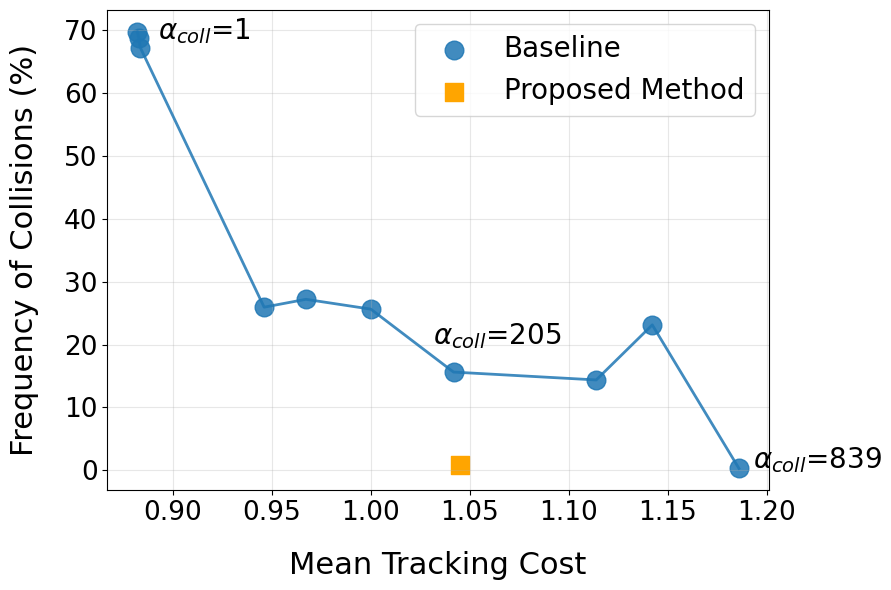

In [8]:
# Final Comparison on Independent Calibration Set + Pareto Curve

import os
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

required_symbols = [
    "set_seed",
    "ExperimentConfig",
    "generate_random_batch",
    "evaluate_model",
    "plt",
]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required definitions: " + ", ".join(missing) + ". Run the setup/definitions cells first."
    )

if "runs" not in globals() or not isinstance(runs, dict):
    raise RuntimeError("`runs` is not available. Run the reload/training cell before this one.")
if runs.get("lagrangian") is None:
    raise RuntimeError("Lagrangian run not available. Run the reload/training cell before this one.")
if len(runs.get("erm_by_lambda", {})) == 0:
    raise RuntimeError("No ERM runs available. Run the reload/training cell before this one.")

if "selected_erm" not in globals():
    # Rebuild selected_erm automatically from currently loaded runs.
    lag_metrics = runs["lagrangian"]["metrics"]
    target_perf = lag_metrics["mean_perf_qr"]
    target_viol_q95 = lag_metrics["violation_quantile_95"]

    erm_candidates = []
    for lam, run in runs["erm_by_lambda"].items():
        m = run["metrics"]
        erm_candidates.append({
            "lambda_obs": lam,
            "run": run,
            "mean_perf_qr": m["mean_perf_qr"],
            "violation_rate": m["violation_rate"],
            "violation_quantile_95": m["violation_quantile_95"],
            "perf_gap": abs(m["mean_perf_qr"] - target_perf),
            "viol_gap": abs(m["violation_quantile_95"] - target_viol_q95),
        })

    best_perf = min(erm_candidates, key=lambda d: d["perf_gap"])
    best_viol = min(erm_candidates, key=lambda d: d["viol_gap"])
    if best_perf["lambda_obs"] == best_viol["lambda_obs"] and len(erm_candidates) > 1:
        best_viol = min(
            [c for c in erm_candidates if c["lambda_obs"] != best_perf["lambda_obs"]],
            key=lambda d: d["viol_gap"],
        )
    selected_erm = {"perf_matched": best_perf, "viol_matched": best_viol}

if "alpha_lagrangian" not in globals():
    alpha_lagrangian = 0.05

# Independent validation/calibration set (fresh seed, separate from fixed_val_w).
set_seed(2026)
m_calib = 320
calib_cfg = ExperimentConfig(alpha_train=alpha_lagrangian)
calib_w = generate_random_batch(calib_cfg, custom_batch_size=m_calib)

lag_run = runs["lagrangian"]
erm_perf_run = selected_erm["perf_matched"]["run"]
erm_viol_run = selected_erm["viol_matched"]["run"]

comparison_runs = [
    ("CVaR Lagrangian", lag_run),
    (f"ERM-RBF perf-matched (lambda={selected_erm['perf_matched']['lambda_obs']:.6f})", erm_perf_run),
    (f"ERM-RBF viol-matched (lambda={selected_erm['viol_matched']['lambda_obs']:.6f})", erm_viol_run),
]

final_results = {}
for name, run in comparison_runs:
    metrics = evaluate_model(run["sim"], run["metric"], calib_w, run["config"] )
    final_results[name] = metrics

print("Independent validation comparison (only Lagrangian + 2 selected ERM models):")
print("-" * 120)
print(f"{'model':>50} | {'mean_perf_qr':>14} | {'viol_q95':>12} | {'collision_%':>12}")
print("-" * 120)
for name, _ in comparison_runs:
    r = final_results[name]
    print(f"{name:>50} | {r['mean_perf_qr']:>14.6f} | {r['violation_quantile_95']:>12.6f} | {100.0*r['violation_rate']:>11.2f}%")
print("-" * 120)

# Pareto: orange dot = Lagrangian, blue dots = all ERM lambdas tried during informed search.
erm_pareto_points = []
for lam, run in sorted(runs["erm_by_lambda"].items(), key=lambda kv: kv[0]):
    metrics = evaluate_model(run["sim"], run["metric"], calib_w, run["config"] )
    erm_pareto_points.append({
        "lambda_obs": lam,
        "mean_perf_qr": metrics["mean_perf_qr"],
        "collision_pct": 100.0 * metrics["violation_rate"],
    })

lag_metrics_calib = final_results["CVaR Lagrangian"]

# ── Pareto plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))

plt.scatter(
    [p["mean_perf_qr"] for p in erm_pareto_points],
    [p["collision_pct"] for p in erm_pareto_points],
    s=180,
    color="tab:blue",
    alpha=0.85,
    label="Baseline",
)

plt.plot(
    [p["mean_perf_qr"] for p in erm_pareto_points],
    [p["collision_pct"] for p in erm_pareto_points],
    color="tab:blue",
    alpha=0.85,
    linewidth=2.0,
)

min_alpha = min(erm_pareto_points, key=lambda d: d["lambda_obs"])
max_alpha = max(erm_pareto_points, key=lambda d: d["lambda_obs"])
alpha_205 = min(erm_pareto_points, key=lambda d: abs(d["lambda_obs"] - 205.0))

label_points = []
seen_lambdas = set()
for p in [min_alpha, alpha_205, max_alpha]:
    lam_key = round(float(p["lambda_obs"]), 6)
    if lam_key not in seen_lambdas:
        label_points.append(p)
        seen_lambdas.add(lam_key)

for p in label_points:
    alpha_i = int(round(p["lambda_obs"]))
    x = p["mean_perf_qr"]
    y = p["collision_pct"]

    # Requested manual placement tweaks for clearer labels.
    dx, dy = 10, 0
    if alpha_i == 1:
        dx, dy = 15, -5
    elif alpha_i == 205:
        dx, dy = -15, 20

    plt.annotate(
        r"$\alpha_{coll}$=" + f"{alpha_i}",
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=20,
    )

plt.scatter(
    [lag_metrics_calib["mean_perf_qr"]],
    [100.0 * lag_metrics_calib["violation_rate"]],
    marker="s",
    s=180,
    color="orange",
    label="Proposed Method",
)

plt.xlabel("Mean Tracking Cost", fontsize=22, labelpad=18)
plt.ylabel("Frequency of Collisions (%)", fontsize=22, labelpad=18)
plt.xticks(fontsize=19)
plt.yticks(fontsize=19)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=20)
plt.tight_layout()

pdf_dir = "figures"
os.makedirs(pdf_dir, exist_ok=True)
pareto_pdf_path = os.path.join(pdf_dir, "cvar_vs_pb_pareto.pdf")
plt.savefig(pareto_pdf_path, format="pdf", bbox_inches="tight")
print(f"Saved Pareto PDF: {pareto_pdf_path}")

plt.show()

## Conformal Bounds

In [9]:
# Certification-style quantile checks on fresh validation sets (alpha=0.05, delta=0.05)
import numpy as np
import torch

alpha_cert = 0.05
delta = 0.05

required_symbols = [
    "runs",
    "evaluate_model",
    "generate_random_batch",
]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required definitions: " + ", ".join(missing) + ". Run setup/reload cells first."
    )
if runs.get("lagrangian") is None or len(runs.get("erm_by_lambda", {})) == 0:
    raise RuntimeError("Required models are not loaded. Run the model reload cell first.")

def epsilon_cert_fn(delta: float, m_cert: int) -> float:
    return float(np.sqrt(np.log(2.0 / delta) / (2.0 * m_cert)))

def smallest_m_for_alpha_minus_eps_gt_zero(alpha: float, delta: float) -> int:
    if alpha <= 0.0:
        raise ValueError("alpha must be > 0 for alpha - epsilon > 0 to be achievable.")
    rhs = np.log(2.0 / delta) / (2.0 * alpha ** 2)
    return int(np.floor(rhs) + 1)

# Match the previous pattern: a fixed m plus the theoretical minimum m ensuring alpha-epsilon > 0.
m_cert_1 = 1200
m_cert_2 = smallest_m_for_alpha_minus_eps_gt_zero(alpha_cert, delta)
m_cert_values = [m_cert_1, m_cert_2]

# Use CVaR plus the two selected ERM checkpoints if available; otherwise fallback to all ERM runs.
if "selected_erm" in globals():
    models_to_check = [
        ("CVaR Lagrangian", runs["lagrangian"]),
        (f"ERM-RBF perf-matched (lambda={selected_erm['perf_matched']['lambda_obs']:.6f})", selected_erm["perf_matched"]["run"]),
        (f"ERM-RBF viol-matched (lambda={selected_erm['viol_matched']['lambda_obs']:.6f})", selected_erm["viol_matched"]["run"]),
    ]
else:
    models_to_check = [("CVaR Lagrangian", runs["lagrangian"])]
    for lam, run in sorted(runs["erm_by_lambda"].items(), key=lambda kv: kv[0]):
        models_to_check.append((f"ERM-RBF(lambda={lam:.6f})", run))

print("Certification quantile levels:")
for m_cert in m_cert_values:
    eps = epsilon_cert_fn(delta, m_cert)
    alpha_minus = alpha_cert - eps
    alpha_plus = alpha_cert + eps
    q_1_minus_alpha_plus_eps = 1.0 - alpha_plus
    q_1_minus_alpha_minus_eps = 1.0 - alpha_minus
    print(
        f"m_cert={m_cert:>5d} | epsilon={eps:.6f} | "
        f"alpha-epsilon={alpha_minus:.6f} | alpha+epsilon={alpha_plus:.6f} | "
        f"1-(alpha+eps)={q_1_minus_alpha_plus_eps:.6f} | 1-(alpha-eps)={q_1_minus_alpha_minus_eps:.6f}"
    )

eval_cfg = runs["lagrangian"]["config"]
val_sets = {
    m_cert: generate_random_batch(eval_cfg, custom_batch_size=m_cert)
    for m_cert in m_cert_values
}

for m_cert in m_cert_values:
    eps = epsilon_cert_fn(delta, m_cert)
    alpha_minus = alpha_cert - eps
    alpha_plus = alpha_cert + eps

    q_collision_low = 1.0 - alpha_plus
    q_collision_high = 1.0 - alpha_minus

    print("\n" + "=" * 170)
    print(f"Validation set size m_cert={m_cert}")
    print(
        f"alpha-epsilon={alpha_minus:.6f}, alpha+epsilon={alpha_plus:.6f}, "
        f"q1=1-(alpha+eps)={q_collision_low:.6f}, q2=1-(alpha-eps)={q_collision_high:.6f}"
    )
    print("-" * 170)
    print(f"{'model':>54} | {'mean_perf_qr':>14} | {'viol_q95':>12} | {'viol_rate':>10} | {'q[1-(a+e)]':>12} | {'q[1-(a-e)]':>12} | {'p_safe_lb_DKWM':>14}")
    print("-" * 170)

    for model_name, run in models_to_check:
        metrics = evaluate_model(run["sim"], run["metric"], val_sets[m_cert], run["config"] )

        max_violation = metrics["maximum_violation"]
        q1 = float(np.clip(q_collision_low, 0.0, 1.0))
        q2 = float(np.clip(q_collision_high, 0.0, 1.0))
        q1_val = torch.quantile(max_violation, q1).item()
        q2_val = torch.quantile(max_violation, q2).item()

        # DKWM lower bound for safety satisfaction probability: max(0, g_hat_safe - eps).
        tau_safe_bar = float(getattr(run["config"], "tau_safe_bar", 0.0))
        g_hat_safe = (max_violation <= tau_safe_bar).float().mean().item()
        p_safe_lb_dkwm = max(0.0, g_hat_safe - eps)

        print(
            f"{model_name:>54} | {metrics['mean_perf_qr']:>14.6f} | {metrics['violation_quantile_95']:>12.6f} | "
            f"{metrics['violation_rate']:>9.2%} | {q1_val:>12.6f} | {q2_val:>12.6f} | {p_safe_lb_dkwm:>14.6f}"
        )

    print("-" * 170)

Certification quantile levels:
m_cert= 1200 | epsilon=0.039205 | alpha-epsilon=0.010795 | alpha+epsilon=0.089205 | 1-(alpha+eps)=0.910795 | 1-(alpha-eps)=0.989205
m_cert=  738 | epsilon=0.049992 | alpha-epsilon=0.000008 | alpha+epsilon=0.099992 | 1-(alpha+eps)=0.900008 | 1-(alpha-eps)=0.999992

Validation set size m_cert=1200
alpha-epsilon=0.010795, alpha+epsilon=0.089205, q1=1-(alpha+eps)=0.910795, q2=1-(alpha-eps)=0.989205
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                 model |   mean_perf_qr |     viol_q95 |  viol_rate |   q[1-(a+e)] |   q[1-(a-e)] | p_safe_lb_DKWM
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                       CVaR Lagrangian |       1.038632 |    -0.04

## Trajectories Plots

Using ERM model with lambda_obs=204.800000 (closest to 205).
Saved trajectory PDF: figures/cvar_vs_pb_traj_erm_alpha205.pdf


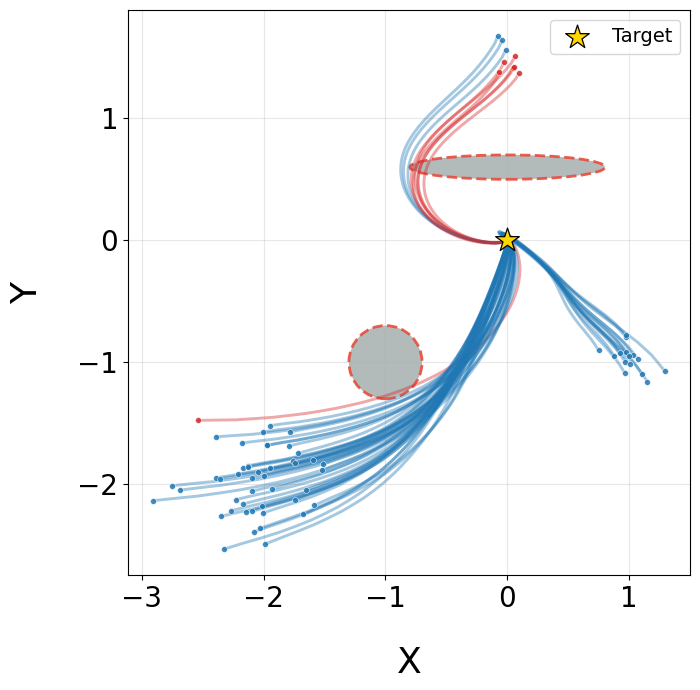

Saved trajectory PDF: figures/cvar_vs_pb_traj_cvar.pdf


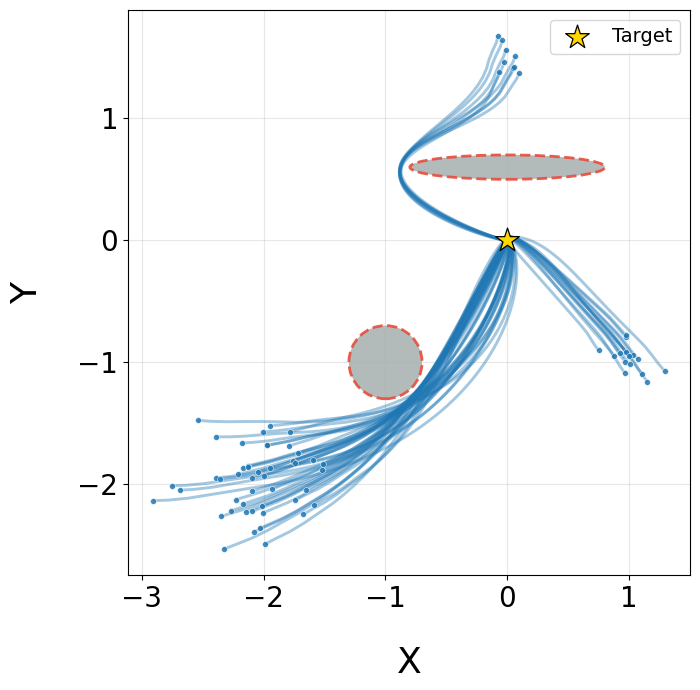

In [10]:
# Separate trajectory maps: ERM alpha_ca~205 and CVaR

import os
from matplotlib.collections import LineCollection
import matplotlib.patches as patches

required_symbols = [
    "runs",
    "set_seed",
    "generate_random_batch",
    "np",
    "torch",
    "plt",
]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required definitions: " + ", ".join(missing) + ". Run setup/reload cells first."
    )

if runs.get("lagrangian") is None or len(runs.get("erm_by_lambda", {})) == 0:
    raise RuntimeError("Required models are not loaded. Run the model reload cell first.")

# Pick the ERM model whose lambda_obs is closest to 205.
erm_lambda_205 = min(runs["erm_by_lambda"].keys(), key=lambda l: abs(float(l) - 205.0))
erm_205_run = runs["erm_by_lambda"][erm_lambda_205]
cvar_run = runs["lagrangian"]

print(f"Using ERM model with lambda_obs={erm_lambda_205:.6f} (closest to 205).")

# Restore original trajectory count used in the first combined-plot version.
eval_cfg = cvar_run["config"]
set_seed(2031)
n_overlay = min(80, getattr(eval_cfg, "num_plot_samples", 200))
overlay_w = generate_random_batch(eval_cfg, custom_batch_size=n_overlay)

with torch.no_grad():
    traj_x_cvar, _, _ = cvar_run["sim"].run(overlay_w)
    traj_x_205, _, _ = erm_205_run["sim"].run(overlay_w)

traj_x_cvar_np = traj_x_cvar.detach().cpu().numpy()
traj_x_205_np = traj_x_205.detach().cpu().numpy()

if traj_x_cvar_np.ndim == 4:
    traj_x_cvar_np = traj_x_cvar_np.squeeze(2)
if traj_x_205_np.ndim == 4:
    traj_x_205_np = traj_x_205_np.squeeze(2)

# Handle multi-agent states by plotting the first agent XY coordinates.
ix, iy = 0, 1

pdf_dir = "figures"
os.makedirs(pdf_dir, exist_ok=True)

def trajectory_collision_mask(traj_np):
    traj_t = torch.as_tensor(traj_np, dtype=torch.float32, device=eval_cfg.device)
    max_violation = compute_maximum_violation(traj_t, eval_cfg).detach().cpu().numpy()
    return max_violation > 0.0

def draw_single_model_figure(traj_np, pdf_filename):
    fig, ax = plt.subplots(figsize=(9, 7))

    # Obstacles (physical + safety ellipses) from the config.
    for center, radii, radii_safe in zip(eval_cfg.obs_centers, eval_cfg.obs_radii, eval_cfg.obs_radii_safe):
        c = center.detach().cpu().numpy() if isinstance(center, torch.Tensor) else np.array(center)
        rx, ry = float(radii[0]), float(radii[1])
        rsx, rsy = float(radii_safe[0]), float(radii_safe[1])

        obs = patches.Ellipse(
            xy=c, width=2 * rx, height=2 * ry,
            facecolor="#7f8c8d", edgecolor="none", alpha=0.6, zorder=1
        )
        safe = patches.Ellipse(
            xy=c, width=2 * rsx, height=2 * rsy,
            fill=False, edgecolor="#e74c3c", linestyle="--", linewidth=2.0, alpha=0.9, zorder=2
        )
        ax.add_patch(obs)
        ax.add_patch(safe)

    # Target (ball destination) and keep only this item in legend.
    target_handle = ax.scatter(
        0.0, 0.0, marker="*", s=320, c="gold", edgecolors="black", linewidths=0.9, zorder=6, label="Target"
    )

    n_plot = min(70, traj_np.shape[0])
    collision_mask = trajectory_collision_mask(traj_np[:n_plot])

    for b in range(n_plot):
        color = "tab:red" if collision_mask[b] else "tab:blue"
        points = np.column_stack([traj_np[b, :, ix], traj_np[b, :, iy]])
        lc = LineCollection([points], colors=[color], linewidths=2.1, alpha=0.4, zorder=3)
        ax.add_collection(lc)
        ax.scatter(
            traj_np[b, 0, ix],
            traj_np[b, 0, iy],
            s=18,
            c=color,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.4,
            zorder=5,
        )

    ax.autoscale()
    ax.set_aspect("equal")
    ax.set_xlabel("X", fontsize=26, labelpad=24)
    ax.set_ylabel("Y", fontsize=26, labelpad=24)
    ax.tick_params(axis="both", labelsize=20)
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[target_handle], labels=["Target"], fontsize=14, loc="best")
    plt.tight_layout()

    pdf_path = os.path.join(pdf_dir, pdf_filename)
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    print(f"Saved trajectory PDF: {pdf_path}")

    plt.show()

draw_single_model_figure(traj_x_205_np, pdf_filename="cvar_vs_pb_traj_erm_alpha205.pdf")
draw_single_model_figure(traj_x_cvar_np, pdf_filename="cvar_vs_pb_traj_cvar.pdf")